In [1445]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import datetime
from datetime import date
sns.set()

In [1446]:
import os
from glob import glob
files = glob('../data/raw/kamis_scraped/*.csv')
# files = [x for x in os.listdir('../data/raw/kamis_scraped/') if '.csv' in x]
df = pd.concat([pd.read_csv(x) for x in files])



df = df[~((df.Commodity == 'Dry Maize')&(df.Classification.isin(['-', 'IRR'])))]
df = df[~((df.Commodity == 'Rice')&(df.Classification.isin(['-', 'Yellow Maize'])))]
df = df[~((df.Commodity == 'Ground Nuts')&(df.Classification.isin(['-', 'Hybrid/ polished'])))]
df = df[~((df.Commodity == 'Green Grams')&(df.Classification.isin(['-'])))]

df['date'] = pd.to_datetime(df['Date'])
df['year'] = df['date'].dt.isocalendar().year
df['week'] = df['date'].dt.isocalendar().week
week_of_year = df['year'].astype(int).astype(str) + '-' + df['week'].astype(int).astype(str).str.zfill(2)
df['year_week'] = pd.to_datetime(week_of_year + '-1', format='%G-%V-%u')
df['day_of_week'] = df['date'].dt.isocalendar().day

df = df.sort_values('date').reset_index(drop=True)
df['Wholesale'] = df['Wholesale'].str.split('/').str[0]
df['Retail'] = df['Retail'].str.split('/').str[0]
df['price'] = pd.to_numeric(df['Wholesale'], errors='coerce')
df['retail'] = pd.to_numeric(df['Retail'], errors = 'coerce')

df['Commodity'] = df['Commodity'].str.strip().str.lower().str.replace('_', ' ').str.title()
df['Classification'] = df['Classification'].str.strip().str.lower().str.replace('_', ' ').str.title()

df['grain'] = df['Commodity'] + '__' + df['Classification']
print(df['grain'].value_counts())

# Drop unnecessary columns
df.drop(['Grade', 'Sex'], axis=1, inplace=True)

grain
Beans (Yellow-Green)__-           19550
Red Sorghum__-                    19122
Beans Red Haricot (Wairimu)__-    13989
Ground Nuts__Large Brown          11800
Dry Maize__White Maize            10519
Rice__Pishori                      9715
Wheat__-                           9572
Green Grams__Hybrid/ Polished      6537
Rice__Sindano                      6294
Ground Nuts__Small Red             5424
Green Grams__Makueni               4538
Green Grams__Local-Special         3925
Dry Maize__Mixed-Traditional       2891
Rice__Irr                          2648
Dry Maize__Yellow Maize            1497
Name: count, dtype: int64


In [1447]:
df.isna().mean()

Commodity         0.000000
Classification    0.000000
Market            0.000000
Wholesale         0.000000
Retail            0.000000
Supply Volume     0.322002
County            0.001648
Date              0.000000
date              0.000000
year              0.000000
week              0.000000
year_week         0.000000
day_of_week       0.000000
price             0.117457
retail            0.110201
grain             0.000000
dtype: float64

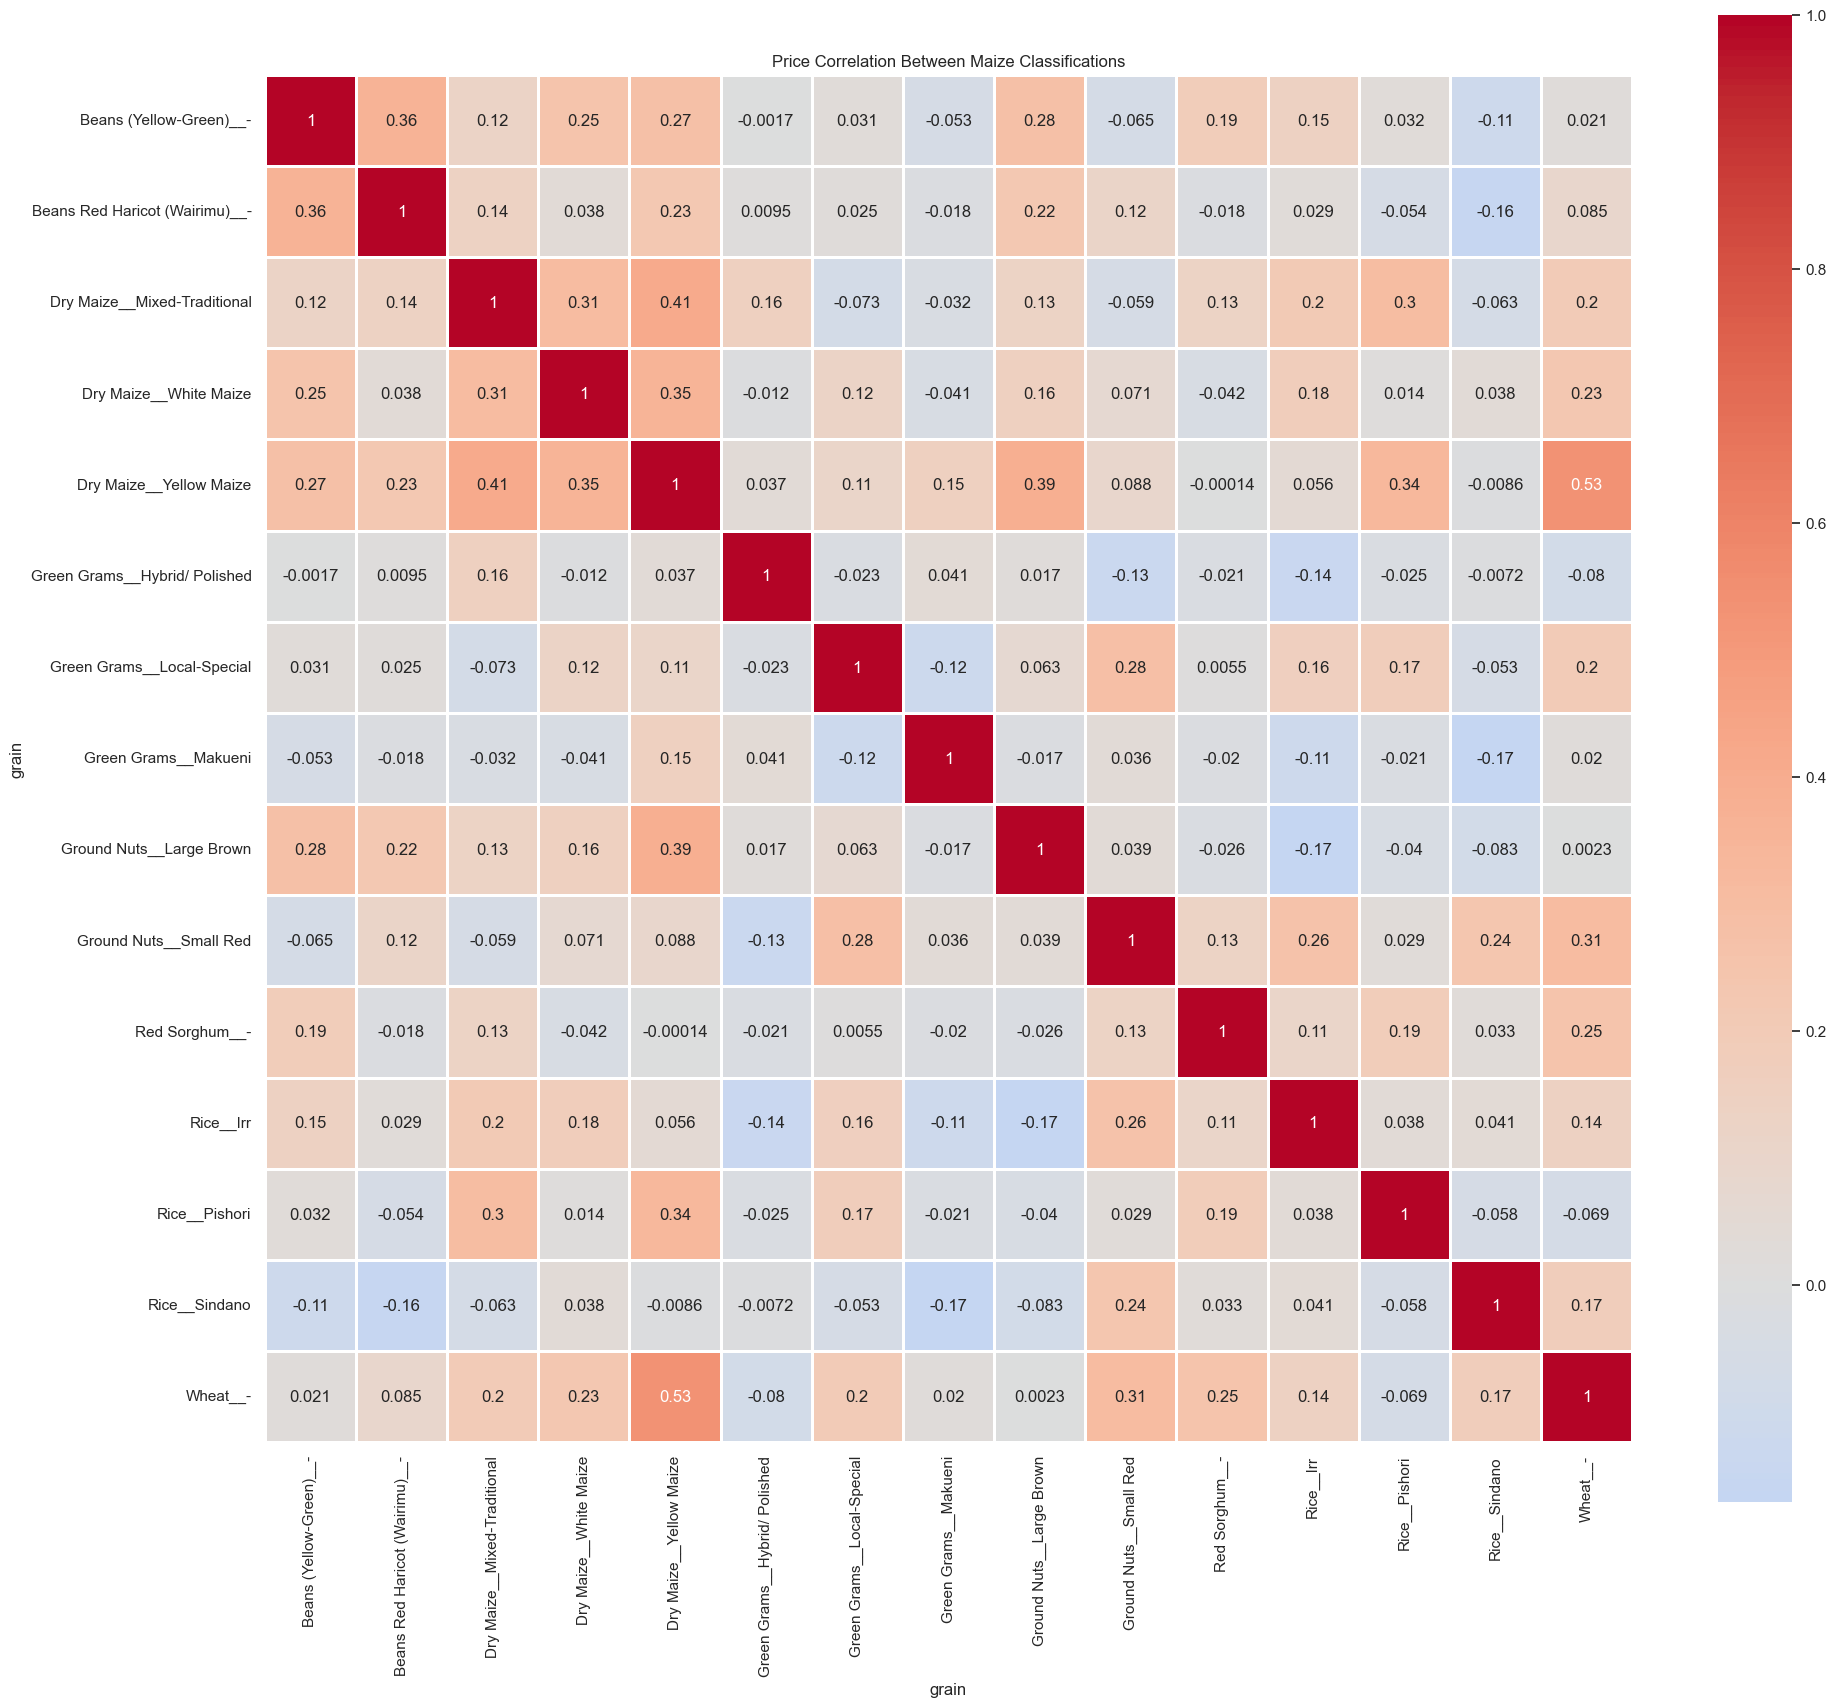

In [1448]:
import seaborn as sns

target_counties = {"Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"}
filtered_data = df[df['County'].isin(target_counties)]

pivot_data = filtered_data.pivot_table(values='price', index='year_week', columns='grain', aggfunc='mean')
# Calculate correlation
correlation = pivot_data.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Price Correlation Between Maize Classifications')
plt.tight_layout()
plt.show()

In [475]:
relevant_grains = correlation.loc['Dry Maize__White Maize', :].abs().sort_values(ascending=False).head(8).to_dict()

In [476]:
relevant_grains

{'Dry Maize__White Maize': 1.0,
 'Dry Maize__Yellow Maize': 0.3529568884182022,
 'Dry Maize__Mixed-Traditional': 0.30568942726425535,
 'Beans (Yellow-Green)__-': 0.254445151795528,
 'Wheat__-': 0.22919675573241463,
 'Rice__Irr': 0.1772929810821721,
 'Ground Nuts__Large Brown': 0.15819549405013422,
 'Green Grams__Local-Special': 0.12248385778145288}

<Axes: xlabel='year_week', ylabel='price'>

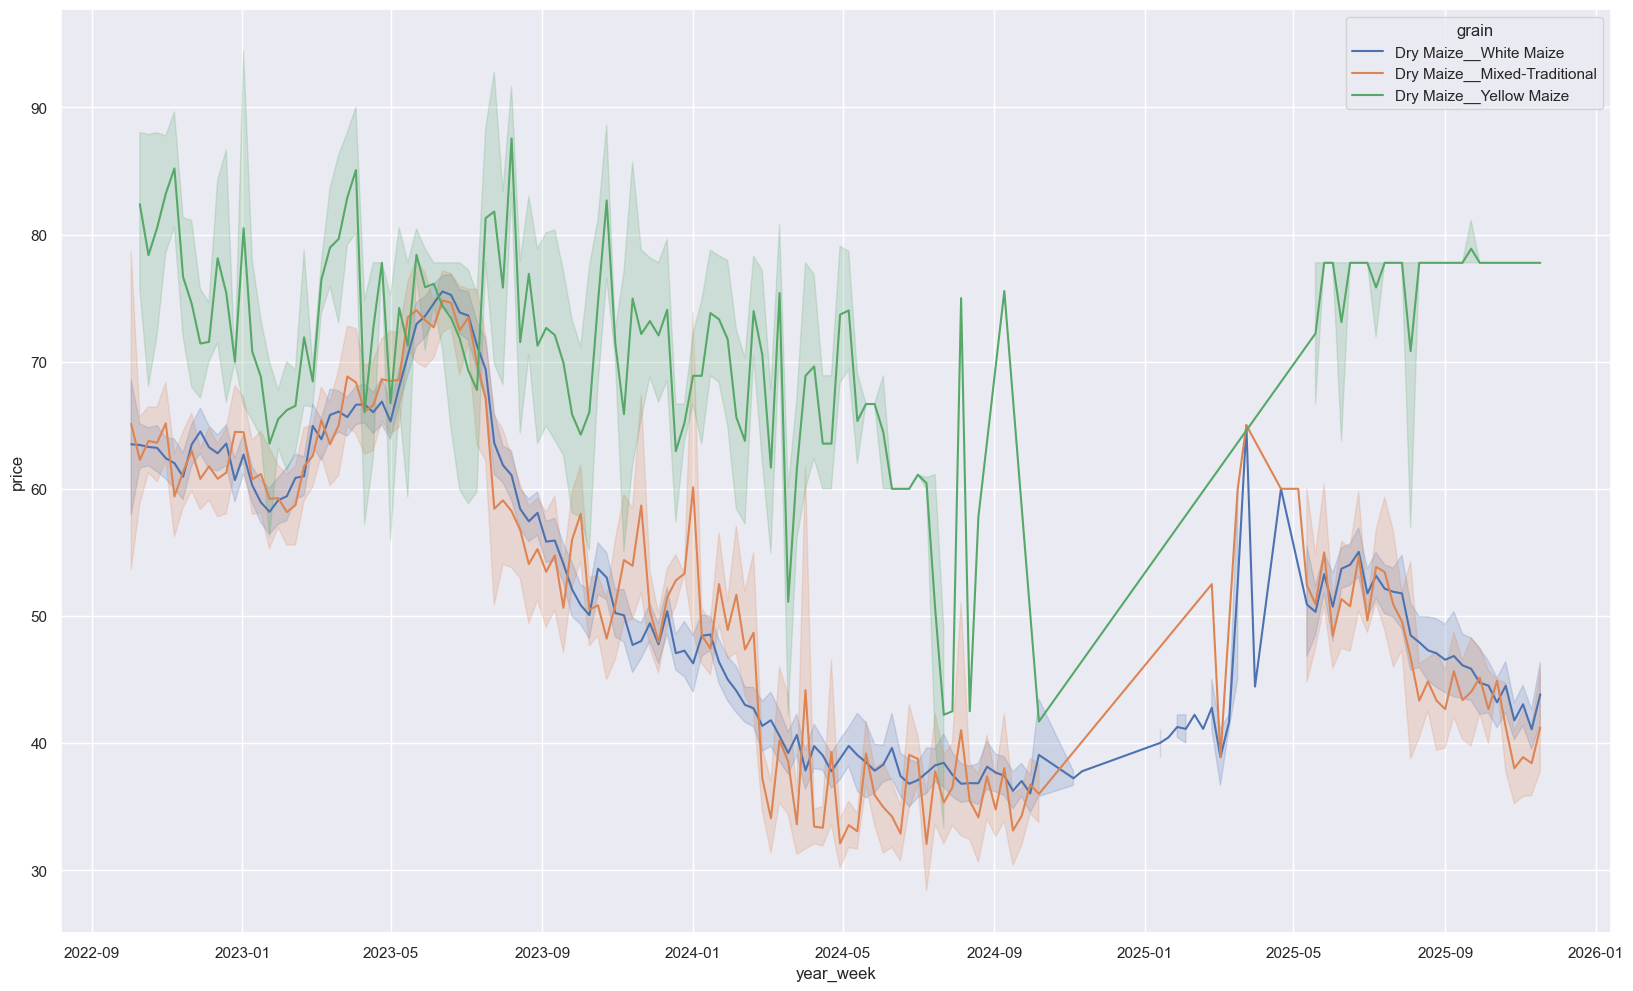

In [7]:
df = df[df.date > df[df.grain == 'Dry Maize__White Maize']['date'].min()]
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'year_week', y = 'price', hue = 'grain', data = df[(df.price < 100)&(df.price > 25)&(df.grain.apply(lambda x: 'Maize' in x))])

In [477]:
df.grain.value_counts()

grain
Beans (Yellow-Green)__-           19550
Red Sorghum__-                    19122
Beans Red Haricot (Wairimu)__-    13989
Ground Nuts__Large Brown          11800
Dry Maize__White Maize            10519
Rice__Pishori                      9715
Wheat__-                           9572
Green Grams__Hybrid/ Polished      6537
Rice__Sindano                      6294
Ground Nuts__Small Red             5424
Green Grams__Makueni               4538
Green Grams__Local-Special         3925
Dry Maize__Mixed-Traditional       2891
Rice__Irr                          2648
Dry Maize__Yellow Maize            1497
Name: count, dtype: int64

In [478]:
filtered_data = df[df['grain'] == 'Dry Maize__White Maize']

pivot_data = filtered_data.pivot_table(values='price', index='year_week', columns='County', aggfunc='mean')
# Calculate correlation
correlation = pivot_data.corr()
# plt.figure(figsize=(20, 20))
# sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
#             square=True, linewidths=1, cbar_kws={"shrink": 0.8})
# plt.title('Price Correlation Between Maize Classifications')
# plt.tight_layout()
# plt.show()

In [479]:
relevant_counties = []
target_counties = {"Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"}

for county in target_counties:
    relevant_counties.extend(list(correlation.loc[county, :].abs().sort_values(ascending=False).head(8).index))

relevant_counties = set(relevant_counties)

In [480]:
relevant_counties

{'Bomet',
 'Busia',
 'Elgeyo-Marakwet',
 'Isiolo',
 'Kajiado',
 'Kakamega',
 'Kericho',
 'Kiambu',
 'Kirinyaga',
 'Kisii',
 'Kisumu',
 'Kitui',
 'Kwale',
 'Machakos',
 'Makueni',
 'Mandera',
 'Mombasa',
 'Muranga',
 'Nairobi',
 'Narok',
 'Samburu',
 'Siaya',
 'Taita-Taveta',
 'Tana-River',
 'Tharaka-Nithi',
 'Turkana',
 'Uasin-Gishu'}

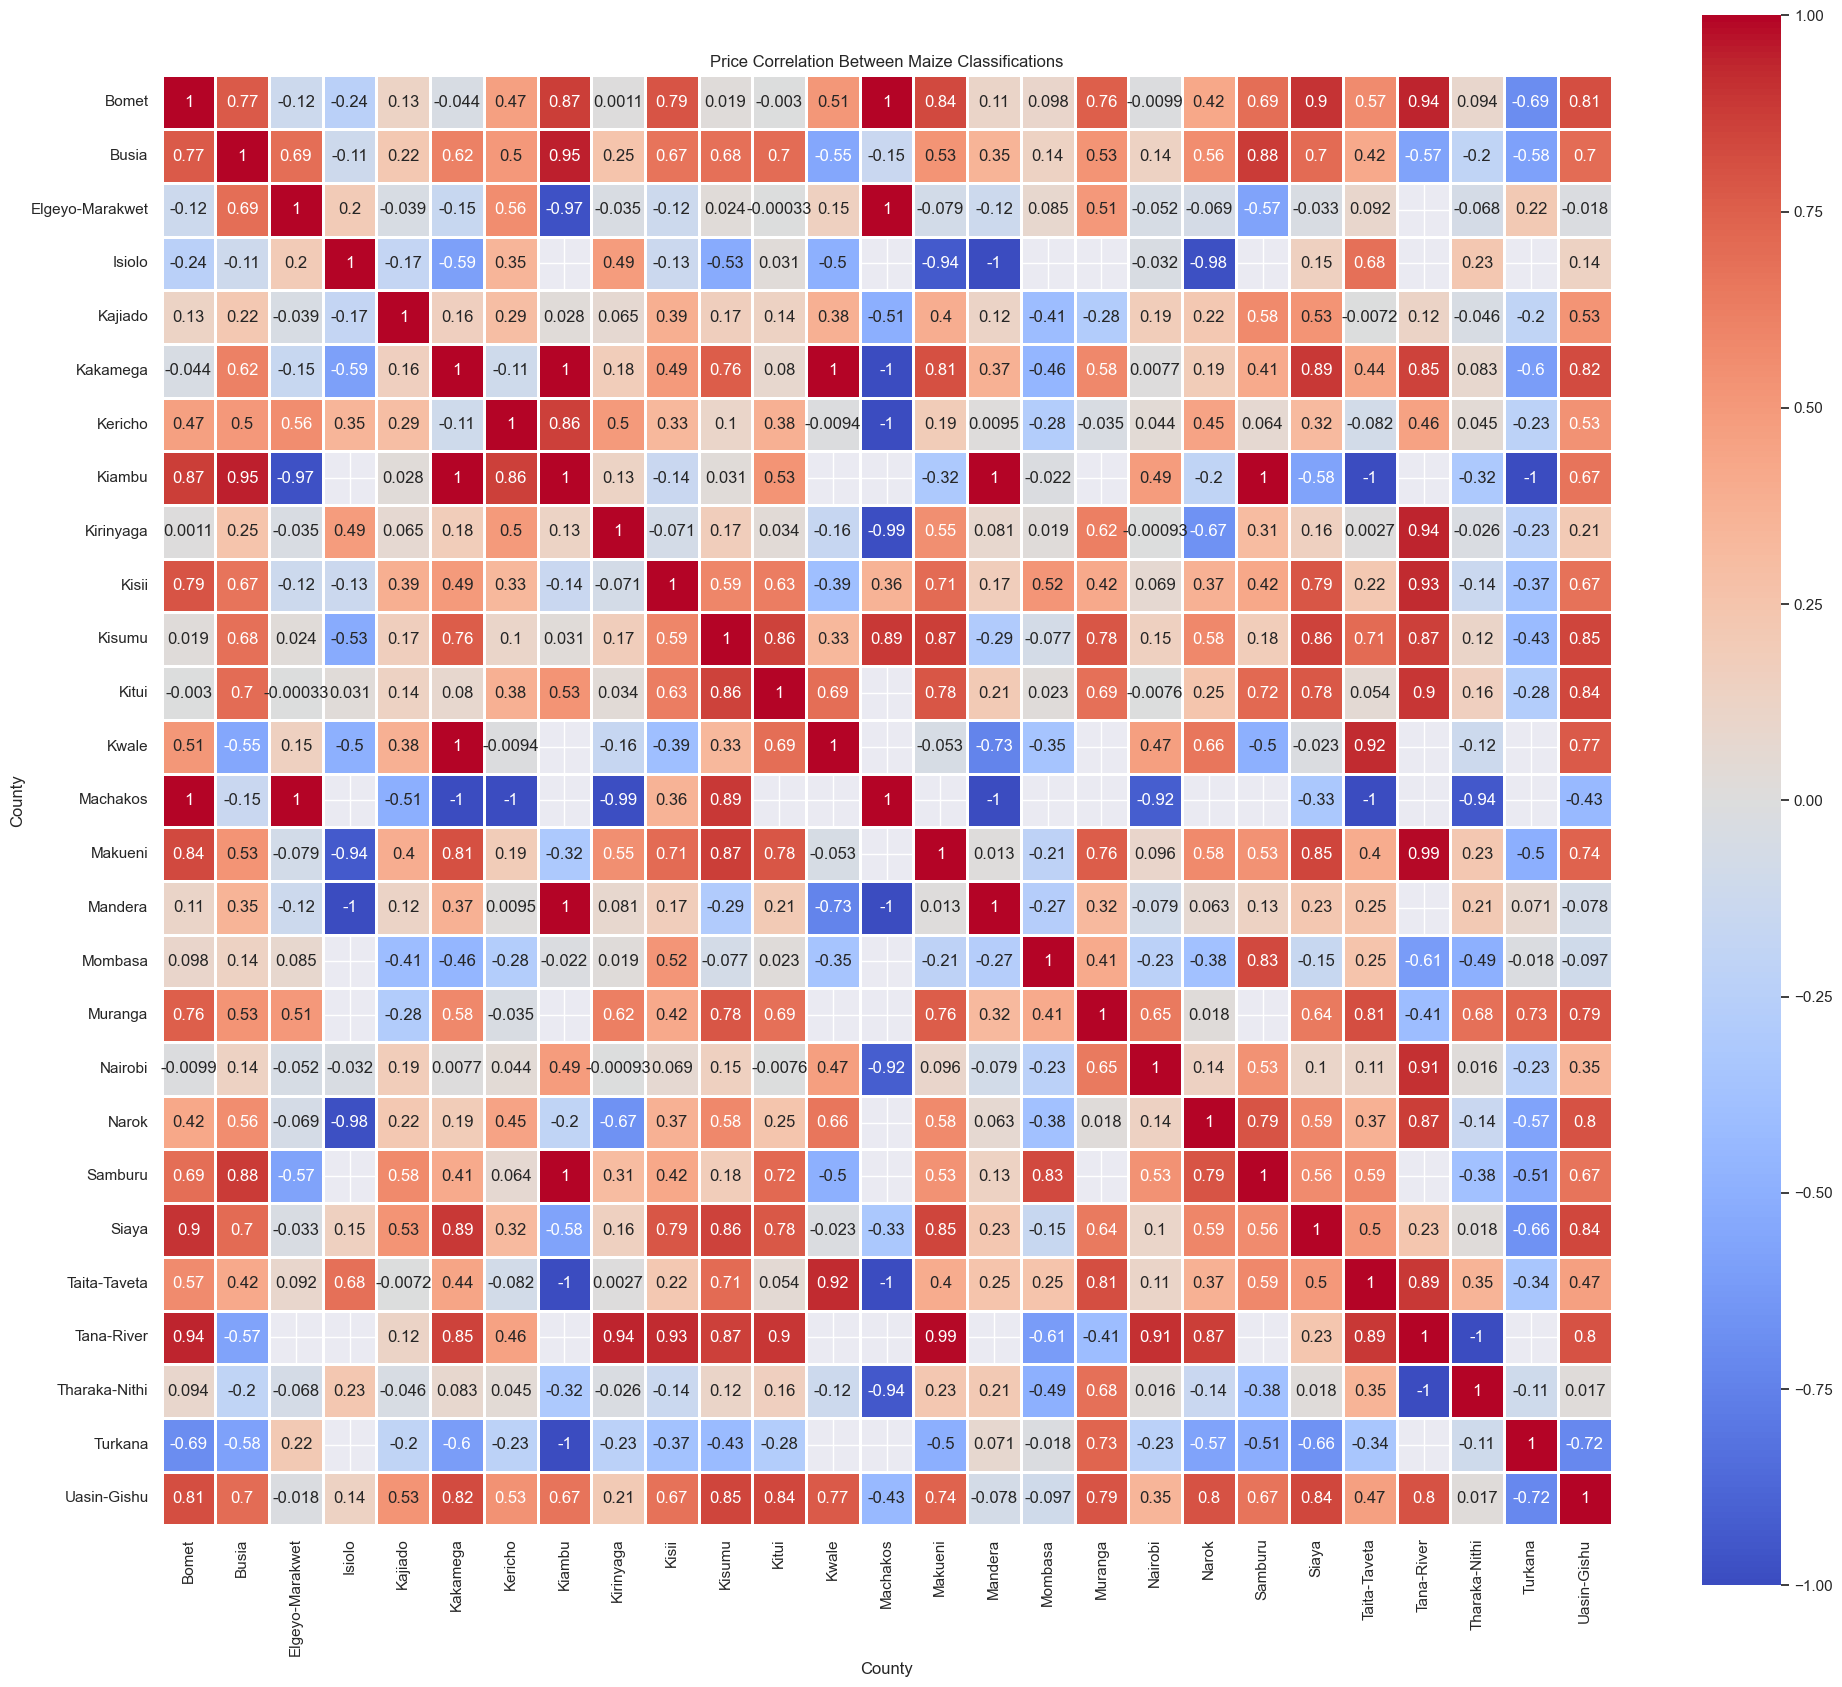

In [481]:
filtered_data = df[df['grain'] == 'Dry Maize__White Maize']

filtered_data = filtered_data[filtered_data.County.isin(relevant_counties)]
pivot_data = filtered_data.pivot_table(values='price', index='year_week', columns='County', aggfunc='mean')
# Calculate correlation
correlation = pivot_data.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Price Correlation Between Maize Classifications')
plt.tight_layout()
plt.show()

# Imputing Data

In [482]:
df_impute = df[df.date > df[df.grain == 'Dry Maize__White Maize']['date'].min()].copy()
# matrix data
df_impute = df_impute[df_impute.retail.notna()]
# df_impute['grain'] = df_impute['grain'].astype('category').cat.codes
# df_impute['County']= df_impute['County'].astype('category').cat.codes
# df_impute['Market'] = df_impute['Market'].astype('category').cat.codes
# df_impute['day_of_week'] = df_impute['day_of_week'].astype('category').cat.codes
# df_impute['year'] = df_impute['year'].astype('category').cat.codes

In [483]:
df_impute.head()

,Commodity,Classification,Market,Wholesale,Retail,Supply Volume,County,Date,date,year,week,year_week,day_of_week,price,retail,grain
47400,Beans Red Haricot (Wairimu),-,Embu Town,133.33,150.00,1500.0,Embu,2022-10-08,2022-10-08,2022,40,2022-10-03,6,133.33,150.0,Beans Red Haricot (Wairimu)__-
47401,Dry Maize,White Maize,Nanyuki Open Air Market,72.22,90.00,4000.0,Laikipia,2022-10-08,2022-10-08,2022,40,2022-10-03,6,72.22,90.0,Dry Maize__White Maize
47402,Beans Red Haricot (Wairimu),-,Akala,100.00,125.00,600.0,Siaya,2022-10-08,2022-10-08,2022,40,2022-10-03,6,100.00,125.0,Beans Red Haricot (Wairimu)__-
47403,Beans Red Haricot (Wairimu),-,Lomut,138.00,120.00,10000.0,West-Pokot,2022-10-08,2022-10-08,2022,40,2022-10-03,6,138.00,120.0,Beans Red Haricot (Wairimu)__-
47404,Beans Red Haricot (Wairimu),-,Nanyuki Open Air Market,100.00,120.00,2000.0,Laikipia,2022-10-08,2022-10-08,2022,40,2022-10-03,6,100.00,120.0,Beans Red Haricot (Wairimu)__-


In [484]:
df_impute['sin_week'] = np.sin(2 * np.pi * df_impute['week'] / 52)
df_impute['cos_week'] = np.cos(2 * np.pi * df_impute['week'] / 52)

In [485]:
df_impute['SV'] = df_impute['Supply Volume']

In [486]:
df_impute[['date', 'grain', 'County', 'Market', 'year','day_of_week', 'retail','sin_week','cos_week', 'price', 'SV']].to_parquet('./../imputerNet/all_data.pq')

In [487]:
df_impute.isna().mean()

Commodity         0.000000
Classification    0.000000
Market            0.000000
Wholesale         0.000000
Retail            0.000000
Supply Volume     0.282352
County            0.000748
Date              0.000000
date              0.000000
year              0.000000
week              0.000000
year_week         0.000000
day_of_week       0.000000
price             0.146439
retail            0.000000
grain             0.000000
sin_week          0.000000
cos_week          0.000000
SV                0.282352
dtype: float64

In [488]:
# import pandas as pd

# df = pd.read_parquet('./../imputerNet/all_data.pq').reset_index()

In [489]:
imp = pd.read_parquet('../imputerNet/imputed_price.pq')
imp.rename({'price':'price_imp'}, axis=1, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'imputerNet/imputed_price.pq'

In [37]:
df_impute = df_impute.reset_index()

In [52]:
imp['price'] = df_impute['price']

In [53]:
imp['pdiff'] = imp['retail'] - imp['price']

In [54]:
imp.pdiff.describe()

count     63852.000000
mean         22.024104
std        1198.468815
min     -199700.000000
25%          10.000000
50%          20.000000
75%          30.560000
max       21800.000000
Name: pdiff, dtype: float64

In [3]:
sv = pd.read_parquet('../imputerNet/imputed_sv.pq')
# imp.rename({'price':'price_imp'}, axis=1, inplace=True)

In [4]:
imp['SV_imp'] = sv['SV']

In [67]:
imp.drop(columns=['pdiff'], axis=1, inplace=True)

In [69]:
imp.to_parquet('COMPLETE_DATA.pq')

In [15]:
subs = imp[imp.grain.isin(relevant_grains)]
subs = subs[subs.County.isin(relevant_counties)]

In [16]:
subs = subs.reset_index()

In [17]:
for col in ['price_imp', 'retail', 'SV_imp']:
    subs[col] = subs[col].clip(upper = subs[col].quantile(0.95))

In [18]:
subs['week'] = subs['date'].dt.isocalendar().week
week_of_year = subs['year'].astype(int).astype(str) + '-' + subs['week'].astype(int).astype(str).str.zfill(2)
subs['year_week'] = pd.to_datetime(week_of_year + '-1', format='%G-%V-%u')

In [19]:
subs.head()

,index,date,grain,County,Market,year,day_of_week,retail,sin_week,cos_week,price_imp,SV,SV_imp,week,year_week
0,14,2022-10-09,Beans (Yellow-Green)__-,Kisumu,Kibuye,2022,7,140.00,-0.992709,0.120537,124.44,NaN,1685.798096,40,2022-10-03
1,19,2022-10-09,Dry Maize__White Maize,Kakamega,Malimili Livestock Market,2022,7,64.00,-0.992709,0.120537,56.00,8200.0,8200.000000,40,2022-10-03
2,20,2022-10-09,Dry Maize__White Maize,Taita-Taveta,Mghange,2022,7,175.00,-0.992709,0.120537,160.00,1500.0,1500.000000,40,2022-10-03
3,22,2022-10-09,Green Grams__Local-Special,Taita-Taveta,Mghange,2022,7,160.00,-0.992709,0.120537,140.00,900.0,900.000000,40,2022-10-03
4,23,2022-10-09,Green Grams__Local-Special,Kakamega,Malimili Livestock Market,2022,7,148.94,-0.992709,0.120537,136.17,1100.0,1100.000000,40,2022-10-03


<Axes: xlabel='date', ylabel='price_imp'>

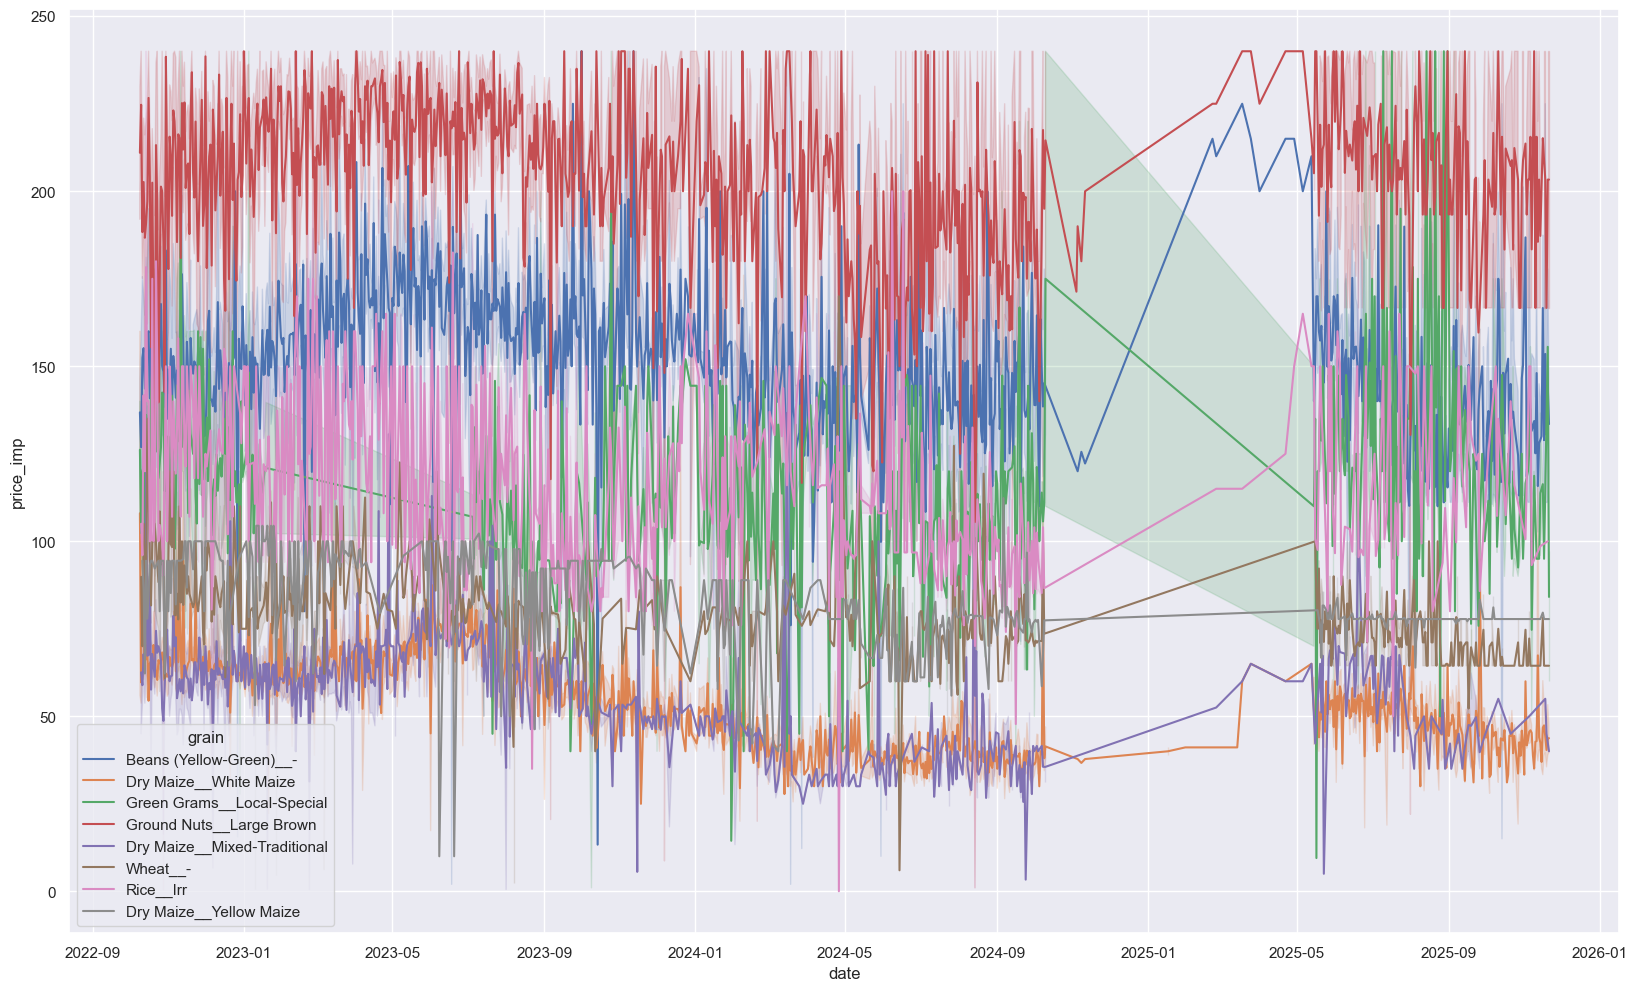

In [86]:
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'date', y = 'price_imp', hue = 'grain', data = subs)

<Axes: xlabel='year_week', ylabel='price_imp'>

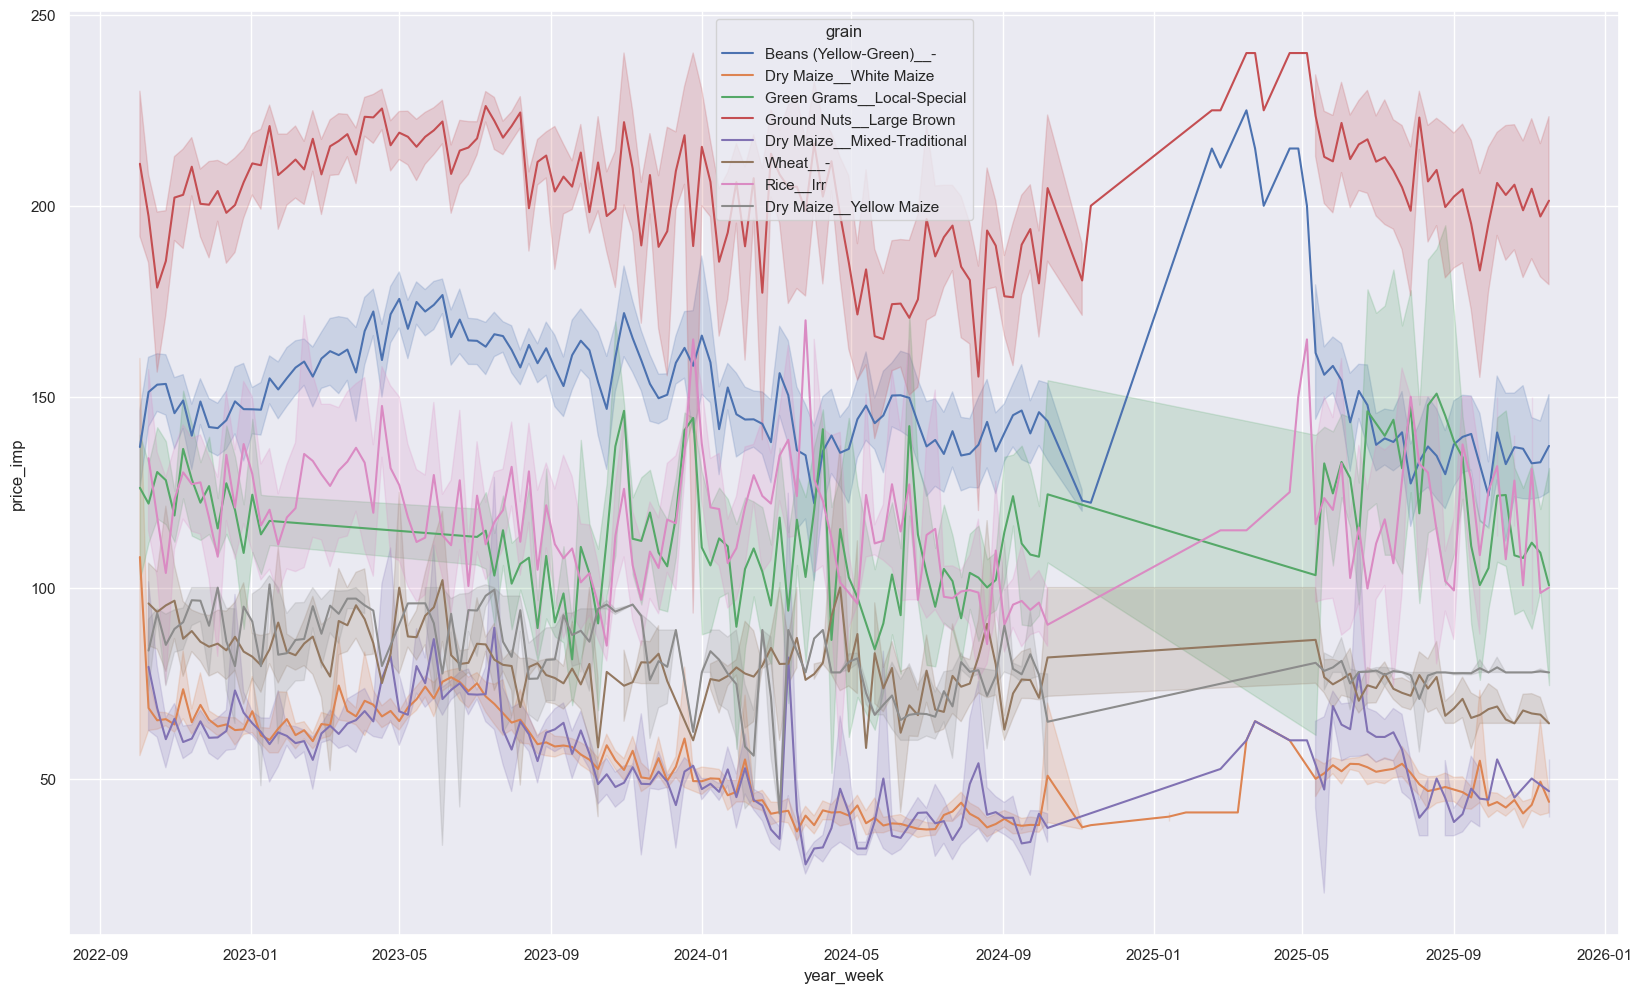

In [20]:
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'year_week', y = 'price_imp', hue = 'grain', data = subs)

NameError: name 'subs' is not defined

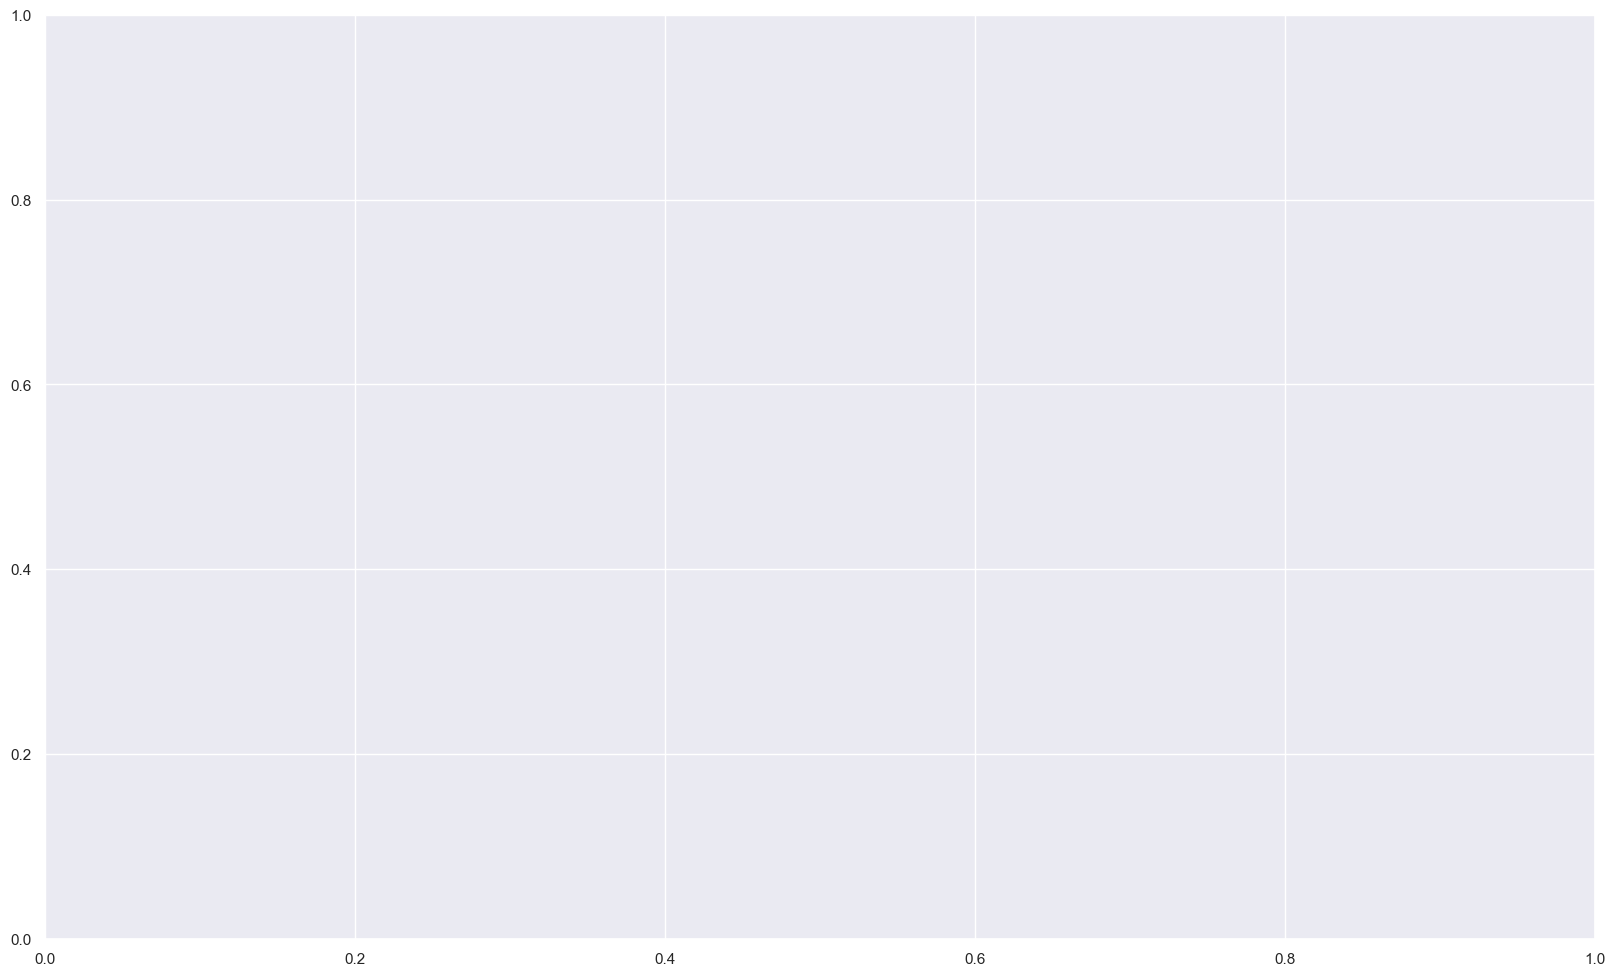

In [1709]:
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'year_week', y = 'SV_imp', hue = 'grain', data = subs)

In [490]:
grped = subs.groupby(['grain', 'County', 'year_week'])[['retail', 'price_imp', 'SV_imp']].agg(['mean', 'median', 'std']).reset_index()

NameError: name 'subs' is not defined

In [1708]:
grped

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,price_imp_mean,price_imp_median,price_imp_std
0,Beans (Yellow-Green)__-,Baringo,2022-10-10,140.000000,140.00,0.000000,120.000000,120.00,0.000000,120.000000,120.000000,0.000000
1,Beans (Yellow-Green)__-,Baringo,2022-10-17,152.500000,150.00,15.000000,126.666667,120.00,11.547005,128.414177,126.828354,10.055051
2,Beans (Yellow-Green)__-,Baringo,2022-10-24,160.000000,160.00,NaN,150.000000,150.00,NaN,150.000000,150.000000,NaN
3,Beans (Yellow-Green)__-,Baringo,2022-10-31,157.500000,155.00,20.615528,130.000000,120.00,17.320508,130.736214,126.472427,14.218581
4,Beans (Yellow-Green)__-,Baringo,2022-11-07,152.500000,150.00,15.000000,132.500000,130.00,15.000000,132.500000,130.000000,15.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
21650,Wheat__-,Vihiga,2023-04-10,271.000000,271.00,NaN,NaN,NaN,NaN,163.311554,163.311554,NaN
21651,Wheat__-,Vihiga,2023-04-17,290.186667,285.71,12.159607,NaN,NaN,NaN,168.959905,168.960999,2.036827
21652,Wheat__-,Vihiga,2023-05-08,314.470000,314.47,NaN,NaN,NaN,NaN,179.797531,179.797531,NaN
21653,Wheat__-,Vihiga,2023-06-05,105.000000,105.00,NaN,91.670000,91.67,NaN,91.670000,91.670000,NaN


In [108]:
grped.year_week.nunique()

149

In [109]:
grped.County.nunique()

27

In [110]:
grped.grain.nunique()

8

In [111]:
149 * 27 * 8

32184

In [494]:
grped.columns = ['grain', 'County', 'year_week', 
                 'retail_mean', 'retail_median', 'retail_std', 
                 'price_mean', 'price_median', 'price_std', 
                 'SV_mean', 'SV_median', 'SV_std', 
                ]

NameError: name 'grped' is not defined

In [495]:
for col in grped.columns:
    if '_std' in col:
        grped[col] = grped[col].fillna(grped[col].mean())

NameError: name 'grped' is not defined

In [496]:
weeks = grped['year_week'].unique()
counties = grped['County'].unique()
grains = grped['grain'].unique()

# Create the full index (The "Ideal" 32k rows)
full_index = pd.MultiIndex.from_product([grains, counties, weeks], names=['grain', 'County', 'year_week'])
df_full = pd.DataFrame(index=full_index).reset_index()

NameError: name 'grped' is not defined

In [498]:
data = pd.merge(df_full, grped, on=['grain', 'County', 'year_week'], how='left')

NameError: name 'df_full' is not defined

In [499]:
data[['grain', 'County', 'year_week']].nunique()

NameError: name 'data' is not defined

In [500]:
df_final = data[['grain', 'County', 'year_week']].copy()

def filler(data, col):
    global df_final
    tmp = data.copy()
    tmp[col] = tmp[col].fillna(-12345)
    df_pivot = tmp.pivot_table(
        index=['County', 'year_week'], 
        columns='grain', 
        values=col
    )
    df_pivot = df_pivot.sort_index(level=['County', 'year_week'])
    df_pivot = df_pivot.replace(-12345, None)
    imputer = IterativeImputer(max_iter=10, random_state=0)
    df_imputed_array = imputer.fit_transform(df_pivot)
    df_imputed = pd.DataFrame(df_imputed_array, columns=df_pivot.columns, index=df_pivot.index)
    df_clean = df_imputed.reset_index().melt(
        id_vars=['County', 'year_week'], 
        var_name='grain', 
        value_name=col
    )
    df_final = df_final.merge(df_clean, how = 'inner', on = ['grain', 'County', 'year_week'])
    return df_final

for col in ['retail_mean', 'retail_median',
       'retail_std', 'price_mean', 'price_median', 'price_std', 'SV_mean',
       'SV_median', 'SV_std']:
    df_final = filler(data, col)

NameError: name 'data' is not defined

In [501]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=0)
df_imputed_array = imputer.fit_transform(df_pivot)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_pivot.columns, index=df_pivot.index)

df_clean = df_imputed.reset_index().melt(
    id_vars=['County', 'year_week'], 
    var_name='grain', 
    value_name='retail_mean'
)

NameError: name 'df_pivot' is not defined

In [1707]:
df_final.isna().mean()

grain               0.0
County              0.0
year_week           0.0
retail_mean         0.0
retail_median       0.0
retail_std          0.0
price_mean          0.0
price_median        0.0
price_std           0.0
price_imp_mean      0.0
price_imp_median    0.0
price_imp_std       0.0
dtype: float64

In [1466]:
df_final.to_parquet('../data/processed/final_exploded_data.pq')

NameError: name 'df_clean' is not defined

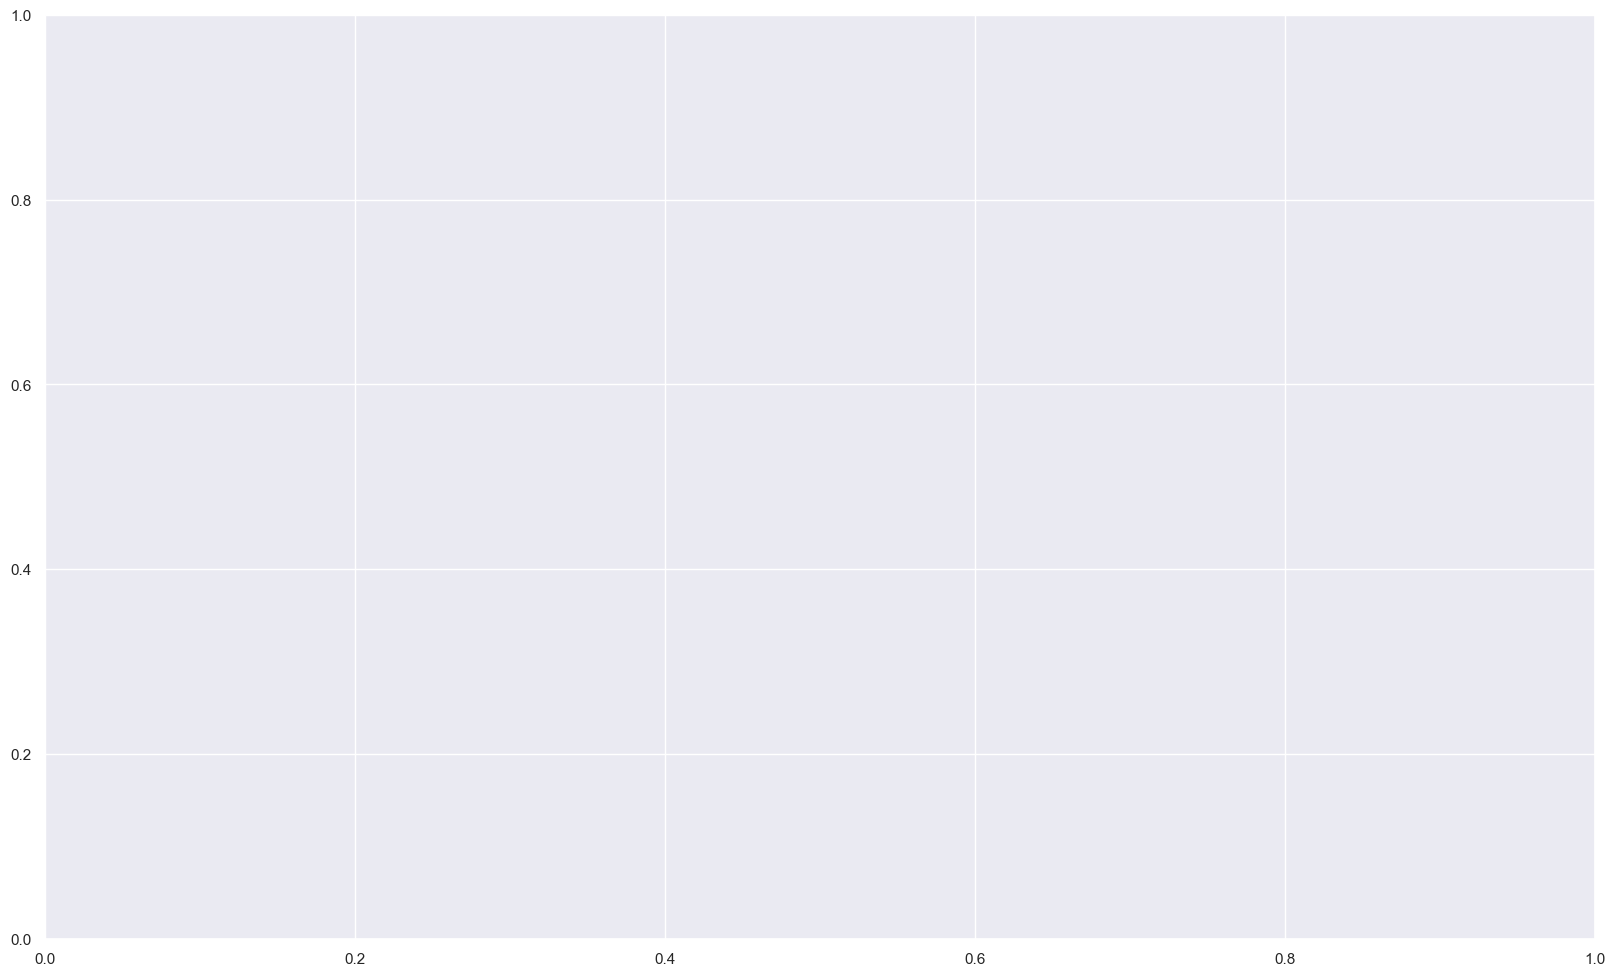

In [1438]:
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'year_week', y = 'retail_mean', hue = 'grain', data = df_clean)

In [ ]:
fig, ax = plt.subplots(figsize = (20, 12))
sns.lineplot(x = 'year_week', y = 'retail_mean', hue = 'grain', data = df_final)

In [1704]:
df_exploded = pd.read_parquet('../data/processed/final_exploded_data.pq')

In [1705]:
df_exploded.columns

Index(['Commodity', 'Classification', 'Market', 'Wholesale', 'Retail',
       'Supply Volume', 'County', 'Date', 'date', 'year', 'week', 'year_week',
       'day_of_week', 'price', 'retail', 'grain', 'price_na', 'grain_coded',
       'County_coded', 'Market_coded', 'sin_week', 'cos_week', 'price_imp'],
      dtype='object')

In [1706]:
df_exploded.head()

,Commodity,Classification,Market,Wholesale,Retail,Supply Volume,County,Date,date,year,...,price,retail,grain,price_na,grain_coded,County_coded,Market_coded,sin_week,cos_week,price_imp
0,Beans Red Haricot (Wairimu),-,Diani Market,150.00,160.00,800.0,Kwale,2022-10-09,2022-10-09,0,...,150.00,160.00,Beans Red Haricot (Wairimu)__-,0,1,18,27,-0.992709,0.120537,150.00
1,Beans Red Haricot (Wairimu),-,Diani Market,150.00,160.00,800.0,Kwale,2022-10-09,2022-10-09,0,...,150.00,160.00,Beans Red Haricot (Wairimu)__-,0,1,18,27,-0.992709,0.120537,150.00
2,Beans Red Haricot (Wairimu),-,Malimili Livestock Market,102.04,114.29,1200.0,Kakamega,2022-10-09,2022-10-09,0,...,102.04,114.29,Beans Red Haricot (Wairimu)__-,0,1,10,123,-0.992709,0.120537,102.04
3,Beans Red Haricot (Wairimu),-,Malimili Livestock Market,102.04,114.29,1200.0,Kakamega,2022-10-09,2022-10-09,0,...,102.04,114.29,Beans Red Haricot (Wairimu)__-,0,1,10,123,-0.992709,0.120537,102.04
4,Beans Red Haricot (Wairimu),-,Kiminini - Kitale,85.00,100.00,100.0,Trans-Nzoia,2022-10-09,2022-10-09,0,...,85.00,100.00,Beans Red Haricot (Wairimu)__-,0,1,40,90,-0.992709,0.120537,85.00


In [1695]:
grped = df_exploded.groupby(['grain', 'County', 'year_week'])[['retail','price','price_imp']].agg(['mean', 'median', 'std']).reset_index()

In [1696]:
grped

grain      County  year_week      retail          \
                                                             mean  median   
0      Beans (Yellow-Green)__-     Baringo 2022-10-10  140.000000  140.00   
1      Beans (Yellow-Green)__-     Baringo 2022-10-17  152.500000  150.00   
2      Beans (Yellow-Green)__-     Baringo 2022-10-24  160.000000  160.00   
3      Beans (Yellow-Green)__-     Baringo 2022-10-31  157.500000  155.00   
4      Beans (Yellow-Green)__-     Baringo 2022-11-07  152.500000  150.00   
...                        ...         ...        ...         ...     ...   
21650                 Wheat__-      Vihiga 2023-04-10  271.000000  271.00   
21651                 Wheat__-      Vihiga 2023-04-17  290.186667  285.71   
21652                 Wheat__-      Vihiga 2023-05-08  314.470000  314.47   
21653                 Wheat__-      Vihiga 2023-06-05  105.000000  105.00   
21654                 Wheat__-  West-Pokot 2023-01-23  170.000000  170.00   

                       price                      price_imp              \
             std        mean  median        std        mean      median   
0       0.000000  120.000000  120.00   0.000000  120.000000  120.000000   
1      15.000000  126.666667  120.00  11.547005  128.414177  126.828354   
2            NaN  150.000000  150.00        NaN  150.000000  150.000000   
3      20.615528  130.000000  120.00  17.320508  130.736214  126.472427   
4      15.000000  132.500000  130.00  15.000000  132.500000  130.000000   
...          ...         ...     ...        ...         ...         ...   
21650        NaN         NaN     NaN        NaN  163.311554  163.311554   
21651  12.159607         NaN     NaN        NaN  168.959905  168.960999   
21652        NaN         NaN     NaN        NaN  179.797531  179.797531   
21653        NaN   91.670000   91.67        NaN   91.670000   91.670000   
21654        NaN  100.000000  100.00        NaN  100.000000  100.000000   

                  
             std  
0       0.000000  
1      10.055051  
2            NaN  
3      14.218581  
4      15.000000  
...          ...  
21650        NaN  
21651   2.036827  
21652        NaN  
21653        NaN  
21654        NaN  

[21655 rows x 12 columns]

In [1697]:
grped.columns = ['grain', 'County', 'year_week',
                 'retail_mean', 'retail_median', 'retail_std', 
                 'price_mean', 'price_median', 'price_std', 
                 'price_imp_mean', 'price_imp_median', 'price_imp_std', 
                ]

In [1698]:
grped

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,price_imp_mean,price_imp_median,price_imp_std
0,Beans (Yellow-Green)__-,Baringo,2022-10-10,140.000000,140.00,0.000000,120.000000,120.00,0.000000,120.000000,120.000000,0.000000
1,Beans (Yellow-Green)__-,Baringo,2022-10-17,152.500000,150.00,15.000000,126.666667,120.00,11.547005,128.414177,126.828354,10.055051
2,Beans (Yellow-Green)__-,Baringo,2022-10-24,160.000000,160.00,NaN,150.000000,150.00,NaN,150.000000,150.000000,NaN
3,Beans (Yellow-Green)__-,Baringo,2022-10-31,157.500000,155.00,20.615528,130.000000,120.00,17.320508,130.736214,126.472427,14.218581
4,Beans (Yellow-Green)__-,Baringo,2022-11-07,152.500000,150.00,15.000000,132.500000,130.00,15.000000,132.500000,130.000000,15.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
21650,Wheat__-,Vihiga,2023-04-10,271.000000,271.00,NaN,NaN,NaN,NaN,163.311554,163.311554,NaN
21651,Wheat__-,Vihiga,2023-04-17,290.186667,285.71,12.159607,NaN,NaN,NaN,168.959905,168.960999,2.036827
21652,Wheat__-,Vihiga,2023-05-08,314.470000,314.47,NaN,NaN,NaN,NaN,179.797531,179.797531,NaN
21653,Wheat__-,Vihiga,2023-06-05,105.000000,105.00,NaN,91.670000,91.67,NaN,91.670000,91.670000,NaN


In [1699]:
def filler(data, col):
    tmp = data[['grain', 'County', 'year_week', col]].copy()

    tmp[col] = tmp[col].fillna(-12345)

    df_pivot = tmp.pivot_table(
        index=['County', 'year_week'],
        columns='grain',
        values=col
    ).sort_index()

    df_pivot = df_pivot.replace(-12345, np.nan)

    imputer = IterativeImputer(max_iter=10, random_state=0)
    df_imputed = pd.DataFrame(
        imputer.fit_transform(df_pivot),
        index=df_pivot.index,
        columns=df_pivot.columns
    )

    df_clean = (
        df_imputed
        .reset_index()
        .melt(
            id_vars=['County', 'year_week'],
            var_name='grain',
            value_name=col
        )
    )

    return df_clean

df_final = grped.copy()

for col in [
    'retail_mean', 'retail_median', 'retail_std',
    'price_mean', 'price_median', 'price_std',
    'price_imp_mean', 'price_imp_median', 'price_imp_std'
]:
    df_clean = filler(df_final, col)

    # DROP old column
    df_final = df_final.drop(columns=[col])

    # MERGE clean column
    df_final = df_final.merge(
        df_clean,
        on=['grain', 'County', 'year_week'],
        how='left'
    )

In [1700]:
df_final.shape

(21655, 12)

In [2]:
df_final.columns

NameError: name 'df_final' is not defined

In [1555]:
target_grain = 'Dry Maize__White Maize'
df_model = df_final[df_final['grain'] == target_grain].copy()

target_counties = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]
df_model = df_model[df_model["County"].isin(target_counties)].copy()

for col in ['retail_mean', 'retail_median',
       'retail_std', 'price_mean', 'price_median', 'price_std', 'price_imp_mean',
       'price_imp_median', 'price_imp_std']:
    
    global_price = df_model.groupby('year_week')[col].mean().reset_index()
    global_price.columns = ['year_week', col]
    for i in range(1, 4):
        global_price[f'global_{col}_{i}'] = global_price[col].shift(i)
        df_model = pd.merge(df_model, global_price[['year_week', f'global_{col}_{i}']], on='year_week', how='left')
        df_model[f'local_{col}_{i}'] = df_model.groupby('County')[col].shift(i)

# Drop initial NaNs generated by shifting
df_model = df_model.dropna()

In [1556]:
df_model.head()

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,price_imp_mean,...,global_price_imp_median_2,local_price_imp_median_2,global_price_imp_median_3,local_price_imp_median_3,global_price_imp_std_1,local_price_imp_std_1,global_price_imp_std_2,local_price_imp_std_2,global_price_imp_std_3,local_price_imp_std_3
3,Dry Maize__White Maize,Kiambu,2023-07-24,76.666667,80.000,5.000000,64.813333,63.330,3.095048,64.813333,...,73.055000,48.89,70.237500,58.89,14.508862,22.021512,10.414773,22.021512,12.894703,22.216242
4,Dry Maize__White Maize,Kiambu,2023-07-31,73.335000,73.335,6.883582,62.225000,62.225,4.590776,62.225000,...,75.463333,61.11,73.055000,48.89,551.412804,3.095048,14.508862,22.021512,10.414773,22.021512
5,Dry Maize__White Maize,Kiambu,2023-08-07,73.335000,73.335,6.883582,61.110000,61.110,1.146403,61.110000,...,69.027500,63.33,75.463333,61.11,5.876642,4.590776,551.412804,3.095048,14.508862,22.021512
9,Dry Maize__White Maize,Kirinyaga,2022-10-31,104.426000,90.000,42.483578,69.678000,70.000,5.300606,69.678000,...,67.130000,72.22,66.945000,70.00,4.015712,4.727885,5.000899,5.459877,85.183567,297.896825
10,Dry Maize__White Maize,Kirinyaga,2022-11-07,88.424286,90.000,10.751886,72.221429,75.000,7.364357,72.221429,...,69.350000,73.61,67.130000,72.22,5.400005,5.300606,4.015712,4.727885,5.000899,5.459877


In [1557]:
df_model.columns

Index(['grain', 'County', 'year_week', 'retail_mean', 'retail_median',
       'retail_std', 'price_mean', 'price_median', 'price_std',
       'price_imp_mean', 'price_imp_median', 'price_imp_std',
       'global_retail_mean_1', 'local_retail_mean_1', 'global_retail_mean_2',
       'local_retail_mean_2', 'global_retail_mean_3', 'local_retail_mean_3',
       'global_retail_median_1', 'local_retail_median_1',
       'global_retail_median_2', 'local_retail_median_2',
       'global_retail_median_3', 'local_retail_median_3',
       'global_retail_std_1', 'local_retail_std_1', 'global_retail_std_2',
       'local_retail_std_2', 'global_retail_std_3', 'local_retail_std_3',
       'global_price_mean_1', 'local_price_mean_1', 'global_price_mean_2',
       'local_price_mean_2', 'global_price_mean_3', 'local_price_mean_3',
       'global_price_median_1', 'local_price_median_1',
       'global_price_median_2', 'local_price_median_2',
       'global_price_median_3', 'local_price_median_3', 'global_

In [1647]:
df_model = df_model.sort_values('year_week')

df_model['week'] = df_model['year_week'].dt.isocalendar().week
df_model['month'] = df_model['year_week'].dt.month
df_model['quarter'] = df_model['year_week'].dt.quarter
df_model['year'] = df_model['year_week'].dt.year

df_model['sin_week'] = np.sin(2 * np.pi * df_model['week'] / 52)
df_model['cos_week'] = np.cos(2 * np.pi * df_model['week'] / 52)

df_model['sin_month'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['cos_month'] = np.cos(2 * np.pi * df_model['month'] / 12)

local_price_mean_1

# Target = week-over-week change
y = df_model['price_mean'] - df_model['local_price_mean_1']

# Drop columns
cols_to_drop = [
    'price_mean', 'price_median', 'price_std', 
    'retail_mean', 'retail_median', 'retail_std', 
    'price_imp_mean', 'price_imp_median', 'price_imp_std', 
    'grain', 'week', 'month', 'quarter', 'year'
]
X = df_model.drop(columns=cols_to_drop)
X['County'] = X['County'].astype('category')

In [1669]:
# Price dynamics
X['price_velocity_1'] = X['local_price_mean_1'] - X['local_price_mean_2']
X['price_velocity_2'] = X['local_price_mean_2'] - X['local_price_mean_3']
X['price_acceleration'] = X['price_velocity_1'] - X['price_velocity_2']

# Volatility features
X['price_volatility'] = X['local_price_std_1']
X['retail_volatility'] = X['local_retail_std_1']

# Ratio features
X['local_vs_global_price'] = X['local_price_mean_1'] / (X['global_price_mean_1'] + 1e-6)
X['local_vs_global_retail'] = X['local_retail_mean_1'] / (X['global_retail_mean_1'] + 1e-6)
X['price_retail_ratio'] = X['local_price_mean_1'] / (X['local_retail_mean_1'] + 1e-6)

# Trend features (comparing lag 1 vs lag 3)
X['price_trend_3week'] = X['local_price_mean_1'] - X['local_price_mean_3']
X['retail_trend_3week'] = X['local_retail_mean_1'] - X['local_retail_mean_3']

# Moving average differences
X['price_ma_diff'] = X['local_price_mean_1'] - ((X['local_price_mean_1'] + X['local_price_mean_2'] + X['local_price_mean_3']) / 3)

KeyError: 'price_mean'

In [1]:
df_model.head()

NameError: name 'df_model' is not defined

In [1649]:
# Get unique weeks sorted
unique_weeks = sorted(df_model['year_week'].unique())
n_weeks = len(unique_weeks)

print(f"Total weeks in data: {n_weeks}")
print(f"Date range: {unique_weeks[0]} to {unique_weeks[-1]}")

# Split:
# - Train: All data except last 18 weeks
# - Validation: Weeks -18 to -7 (12 weeks for validation)
# - Test: Last 6 weeks (to simulate the competition test set)

train_end_idx = n_weeks - 18
val_end_idx = n_weeks - 6

train_weeks = unique_weeks[:train_end_idx]
val_weeks = unique_weeks[train_end_idx:val_end_idx]
test_weeks = unique_weeks[val_end_idx:]

print(f"\nTrain weeks: {len(train_weeks)} ({train_weeks[0]} to {train_weeks[-1]})")
print(f"Validation weeks: {len(val_weeks)} ({val_weeks[0]} to {val_weeks[-1]})")
print(f"Test weeks: {len(test_weeks)} ({test_weeks[0]} to {test_weeks[-1]})")


Total weeks in data: 132
Date range: 2022-10-31 00:00:00 to 2025-11-17 00:00:00

Train weeks: 114 (2022-10-31 00:00:00 to 2025-07-14 00:00:00)
Validation weeks: 12 (2025-07-21 00:00:00 to 2025-10-06 00:00:00)
Test weeks: 6 (2025-10-13 00:00:00 to 2025-11-17 00:00:00)


In [1651]:
train_mask = X['year_week'].isin(train_weeks)
val_mask = X['year_week'].isin(val_weeks)
test_mask = X['year_week'].isin(test_weeks)

X_train = X[train_mask].drop(columns=['year_week'])
X_val = X[val_mask].drop(columns=['year_week'])
X_test = X[test_mask].drop(columns=['year_week'])

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print(f"\nTrain samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")



Train samples: 322
Validation samples: 24
Test samples: 12


In [1652]:
X_train.dtypes

County                    category
global_retail_mean_1       float64
local_retail_mean_1        float64
global_retail_mean_2       float64
local_retail_mean_2        float64
                            ...   
local_vs_global_retail     float64
price_retail_ratio         float64
price_trend_3week          float64
retail_trend_3week         float64
price_ma_diff              float64
Length: 70, dtype: object

In [1653]:
lgbm = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,          # Lower learning rate
    num_leaves=31,
    min_child_samples=20,        # Prevent overfitting
    subsample=0.8,               # Row sampling
    colsample_bytree=0.8,        # Column sampling
    reg_alpha=0.1,               # L1 regularization
    reg_lambda=0.1,              # L2 regularization
    min_split_gain=0.01,
    random_state=42,
    verbosity=-1
)

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    categorical_feature=['County'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("\n" + "="*80)
print("VALIDATION SET PERFORMANCE")
print("="*80)

delta_pred_val = lgbm.predict(X_val)
baseline_price_val = df_model.loc[X_val.index, 'local_price_mean_1']
price_pred_val = baseline_price_val + delta_pred_val
actual_price_val = df_model.loc[X_val.index, 'price_mean']

val_mae = mean_absolute_error(actual_price_val, price_pred_val)
val_rmse = root_mean_squared_error(actual_price_val, price_pred_val)
val_r2 = r2_score(actual_price_val, price_pred_val)
val_mape = mean_absolute_percentage_error(actual_price_val, price_pred_val)

print(f"MAE:  {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²:   {val_r2:.4f}")
print(f"MAPE: {val_mape:.4f}")


TRAINING MODEL
Training until validation scores don't improve for 100 rounds
[100]	train's l2: 35431	val's l2: 148.835
Early stopping, best iteration is:
[1]	train's l2: 43617.3	val's l2: 4.33834

VALIDATION SET PERFORMANCE
MAE:  1.4268
RMSE: 2.0829
R²:   0.8975
MAPE: 0.0336


In [1654]:
if len(X_test) > 0:
    print("\n" + "="*80)
    print("INTERNAL TEST SET PERFORMANCE")
    print("="*80)
    
    delta_pred_test = lgbm.predict(X_test)
    baseline_price_test = df_model.loc[X_test.index, 'local_price_mean_1']
    price_pred_test = baseline_price_test + delta_pred_test
    actual_price_test = df_model.loc[X_test.index, 'price_mean']
    
    test_mae = mean_absolute_error(actual_price_test, price_pred_test)
    test_rmse = root_mean_squared_error(actual_price_test, price_pred_test)
    test_r2 = r2_score(actual_price_test, price_pred_test)
    test_mape = mean_absolute_percentage_error(actual_price_test, price_pred_test)
    
    print(f"MAE:  {test_mae:.4f}")
    print(f"RMSE: {test_rmse:.4f}")
    print(f"R²:   {test_r2:.4f}")
    print(f"MAPE: {test_mape:.4f}")


INTERNAL TEST SET PERFORMANCE
MAE:  3.3641
RMSE: 4.2299
R²:   -1.0705
MAPE: 0.0816


In [1655]:
print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))



TOP 20 MOST IMPORTANT FEATURES
                  feature  importance
        local_price_std_1           4
         price_velocity_1           2
       local_price_mean_1           1
global_price_imp_median_2           1
   local_vs_global_retail           1
    local_vs_global_price           1
    global_price_median_1           1
   global_retail_median_2           1
    local_price_imp_std_1           0
   global_price_imp_std_1           0
 local_price_imp_median_3           0
global_price_imp_median_3           0
 local_price_imp_median_2           0
                   County           0
 local_price_imp_median_1           0
   global_price_imp_std_2           0
   local_price_imp_mean_3           0
  global_price_imp_mean_3           0
   local_price_imp_mean_2           0
  global_price_imp_mean_2           0


In [1684]:
def create_features_for_week(df_history, county, target_date):
    """
    Create features for a specific county and week using historical data
    """
    # Get last 3 weeks of data for this county
    county_data = df_history[df_history['County'] == county].tail(3)
    
    if len(county_data) < 3:
        return None
    
    # Extract lag features from most recent 3 weeks
    lag1 = county_data.iloc[-1]
    lag2 = county_data.iloc[-2]
    lag3 = county_data.iloc[-3]
    
    # Calculate week features
    week_num = pd.Timestamp(target_date).isocalendar().week
    month_num = pd.Timestamp(target_date).month
    quarter_num = pd.Timestamp(target_date).quarter
    
    sin_week = np.sin(2 * np.pi * week_num / 52)
    cos_week = np.cos(2 * np.pi * week_num / 52)
    sin_month = np.sin(2 * np.pi * month_num / 12)
    cos_month = np.cos(2 * np.pi * month_num / 12)
    
    # Build feature dictionary
    features = {
        'County': county,
        'year_week': target_date,
        
        # Retail features
        'global_retail_mean_1': lag1['global_retail_mean_1'],
        'local_retail_mean_1': lag1['local_retail_mean_1'],
        'global_retail_mean_2': lag1['global_retail_mean_2'],
        'local_retail_mean_2': lag1['local_retail_mean_2'],
        'global_retail_mean_3': lag1['global_retail_mean_3'],
        'local_retail_mean_3': lag1['local_retail_mean_3'],
        'global_retail_median_1': lag1['global_retail_median_1'],
        'local_retail_median_1': lag1['local_retail_median_1'],
        'global_retail_median_2': lag1['global_retail_median_2'],
        'local_retail_median_2': lag1['local_retail_median_2'],
        'global_retail_median_3': lag1['global_retail_median_3'],
        'local_retail_median_3': lag1['local_retail_median_3'],
        'global_retail_std_1': lag1['global_retail_std_1'],
        'local_retail_std_1': lag1['local_retail_std_1'],
        'global_retail_std_2': lag1['global_retail_std_2'],
        'local_retail_std_2': lag1['local_retail_std_2'],
        'global_retail_std_3': lag1['global_retail_std_3'],
        'local_retail_std_3': lag1['local_retail_std_3'],
        
        # Price features
        'global_price_mean_1': lag1['global_price_mean_1'],
        'local_price_mean_1': lag1['local_price_mean_1'],
        'global_price_mean_2': lag1['global_price_mean_2'],
        'local_price_mean_2': lag1['local_price_mean_2'],
        'global_price_mean_3': lag1['global_price_mean_3'],
        'local_price_mean_3': lag1['local_price_mean_3'],
        'global_price_median_1': lag1['global_price_median_1'],
        'local_price_median_1': lag1['local_price_median_1'],
        'global_price_median_2': lag1['global_price_median_2'],
        'local_price_median_2': lag1['local_price_median_2'],
        'global_price_median_3': lag1['global_price_median_3'],
        'local_price_median_3': lag1['local_price_median_3'],
        'global_price_std_1': lag1['global_price_std_1'],
        'local_price_std_1': lag1['local_price_std_1'],
        'global_price_std_2': lag1['global_price_std_2'],
        'local_price_std_2': lag1['local_price_std_2'],
        'global_price_std_3': lag1['global_price_std_3'],
        'local_price_std_3': lag1['local_price_std_3'],
        'rolling_mean' : lag1['rolling_mean'],
        
        # Imputed price features
        'global_price_imp_mean_1': lag1['global_price_imp_mean_1'],
        'local_price_imp_mean_1': lag1['local_price_imp_mean_1'],
        'global_price_imp_mean_2': lag1['global_price_imp_mean_2'],
        'local_price_imp_mean_2': lag1['local_price_imp_mean_2'],
        'global_price_imp_mean_3': lag1['global_price_imp_mean_3'],
        'local_price_imp_mean_3': lag1['local_price_imp_mean_3'],
        'global_price_imp_median_1': lag1['global_price_imp_median_1'],
        'local_price_imp_median_1': lag1['local_price_imp_median_1'],
        'global_price_imp_median_2': lag1['global_price_imp_median_2'],
        'local_price_imp_median_2': lag1['local_price_imp_median_2'],
        'global_price_imp_median_3': lag1['global_price_imp_median_3'],
        'local_price_imp_median_3': lag1['local_price_imp_median_3'],
        'global_price_imp_std_1': lag1['global_price_imp_std_1'],
        'local_price_imp_std_1': lag1['local_price_imp_std_1'],
        'global_price_imp_std_2': lag1['global_price_imp_std_2'],
        'local_price_imp_std_2': lag1['local_price_imp_std_2'],
        'global_price_imp_std_3': lag1['global_price_imp_std_3'],
        'local_price_imp_std_3': lag1['local_price_imp_std_3'],
        
        # Temporal features
        'sin_week': sin_week,
        'cos_week': cos_week,
        'sin_month': sin_month,
        'cos_month': cos_month,
    }
    
    # Engineered features
    features['price_velocity_1'] = features['local_price_mean_1'] - features['local_price_mean_2']
    features['price_velocity_2'] = features['local_price_mean_2'] - features['local_price_mean_3']
    features['price_acceleration'] = features['price_velocity_1'] - features['price_velocity_2']
    features['price_volatility'] = features['local_price_std_1']
    features['retail_volatility'] = features['local_retail_std_1']
    features['local_vs_global_price'] = features['local_price_mean_1'] / (features['global_price_mean_1'] + 1e-6)
    features['local_vs_global_retail'] = features['local_retail_mean_1'] / (features['global_retail_mean_1'] + 1e-6)
    features['price_retail_ratio'] = features['local_price_mean_1'] / (features['local_retail_mean_1'] + 1e-6)
    features['price_trend_3week'] = features['local_price_mean_1'] - features['local_price_mean_3']
    features['retail_trend_3week'] = features['local_retail_mean_1'] - features['local_retail_mean_3']
    features['price_ma_diff'] = features['local_price_mean_1'] - (
        (features['local_price_mean_1'] + features['local_price_mean_2'] + features['local_price_mean_3']) / 3
    )
    
    return features

In [1685]:
def update_history_with_prediction(df_history, county, new_date, predicted_price):
    """
    Add a predicted week to history for rolling forecasts
    This updates the lag features for the next prediction
    """
    # Get the most recent row for this county
    latest = df_history[df_history['County'] == county].iloc[-1].copy()
    
    # Shift the lag features: lag1 -> lag2, lag2 -> lag3
    # And set the new prediction as lag1
    new_row = latest.copy()
    new_row['year_week'] = new_date
    
    # Shift price lags
    new_row['local_price_mean_3'] = latest['local_price_mean_2']
    new_row['local_price_mean_2'] = latest['local_price_mean_1']
    new_row['local_price_mean_1'] = predicted_price
    
    new_row['global_price_mean_3'] = latest['global_price_mean_2']
    new_row['global_price_mean_2'] = latest['global_price_mean_1']
    # Keep global price mean 1 the same (we don't predict global)
    
    # Similarly for medians and stds (simplified - keep them shifted)
    new_row['local_price_median_3'] = latest['local_price_median_2']
    new_row['local_price_median_2'] = latest['local_price_median_1']
    new_row['local_price_median_1'] = predicted_price  # Approximate
    
    new_row['local_price_std_3'] = latest['local_price_std_2']
    new_row['local_price_std_2'] = latest['local_price_std_1']
    # Keep std_1 same
    
    # Shift retail lags (assume they stay relatively stable)
    new_row['local_retail_mean_3'] = latest['local_retail_mean_2']
    new_row['local_retail_mean_2'] = latest['local_retail_mean_1']
    # Keep retail_mean_1 same
    
    new_row['local_retail_median_3'] = latest['local_retail_median_2']
    new_row['local_retail_median_2'] = latest['local_retail_median_1']
    
    new_row['local_retail_std_3'] = latest['local_retail_std_2']
    new_row['local_retail_std_2'] = latest['local_retail_std_1']
    
    # Imputed prices
    new_row['local_price_imp_mean_3'] = latest['local_price_imp_mean_2']
    new_row['local_price_imp_mean_2'] = latest['local_price_imp_mean_1']
    new_row['local_price_imp_mean_1'] = predicted_price
    
    new_row['local_price_imp_median_3'] = latest['local_price_imp_median_2']
    new_row['local_price_imp_median_2'] = latest['local_price_imp_median_1']
    new_row['local_price_imp_median_1'] = predicted_price
    
    new_row['local_price_imp_std_3'] = latest['local_price_imp_std_2']
    new_row['local_price_imp_std_2'] = latest['local_price_imp_std_1']
    
    # Append to history
    return pd.concat([df_history, pd.DataFrame([new_row])], ignore_index=True)


In [1686]:

# Define target dates for prediction (weeks 48-52 of 2024, weeks 1-2 of 2025)
# ADJUST THESE DATES based on your actual data!
target_dates = [
    '2025-11-24',  # Week 48 (Monday of week 48)
    '2025-12-01',  # Week 49
    '2025-12-08',  # Week 50
    '2025-12-15',  # Week 51
    '2025-12-22',  # Week 52
    '2025-12-29',  # Week 1 of 2026
    '2026-01-05',  # Week 2 of 2026
]
# Convert to datetime
target_dates = [pd.to_datetime(d) for d in target_dates]

# Get list of counties
counties = df_model['County'].unique()

# Initialize prediction storage
all_predictions = []

# Create a copy of df_model for rolling updates
df_rolling = df_model.copy()

print("\n" + "="*80)
print("GENERATING ROLLING FORECASTS FOR COMPETITION")
print("="*80)

# Rolling forecast: predict each week and update history
for target_date in target_dates:
    week_num = target_date.isocalendar().week
    print(f"\nPredicting Week {week_num} ({target_date.date()})...")
    
    week_predictions = []
    
    for county in counties:
        # Create features for this county and week
        features = create_features_for_week(df_rolling, county, target_date)
        
        if features is None:
            print(f"  Warning: Insufficient data for {county}")
            continue
        
        week_predictions.append(features)
    
    if len(week_predictions) == 0:
        print(f"  No predictions for week {week_num}")
        continue
    
    # Convert to DataFrame
    X_pred = pd.DataFrame(week_predictions)
    
    # Prepare for model prediction
    baseline_prices = X_pred['local_price_mean_1'].values
    X_pred_model = X_pred.drop(columns=['year_week']).copy()
    X_pred_model['County'] = X_pred_model['County'].astype('category')
    
    # Predict deltas
    delta_pred = lgbm.predict(X_pred_model)
    
    # Calculate final prices
    price_pred = baseline_prices + delta_pred
    
    # Store predictions
    for i, county in enumerate(X_pred['County']):
        all_predictions.append({
            'County': county,
            'year_week': target_date,
            'week': week_num,
            'predicted_price': price_pred[i],
            'baseline_price': baseline_prices[i],
            'predicted_delta': delta_pred[i]
        })
        
        # Update rolling history with this prediction
        df_rolling = update_history_with_prediction(
            df_rolling, 
            county, 
            target_date, 
            price_pred[i]
        )
    
    print(f"  Predicted for {len(X_pred)} counties")
    print(f"  Mean predicted price: {price_pred.mean():.2f}")
    print(f"  Price range: [{price_pred.min():.2f}, {price_pred.max():.2f}]")

# ============================================================================
# FORMAT PREDICTIONS FOR SUBMISSION
# ============================================================================

predictions_df = pd.DataFrame(all_predictions)

# Create submission format: County__Week__XX
predictions_df['ID'] = (
    predictions_df['County'] + '_Week_' + predictions_df['week'].astype(str)
)

# Create final submission dataframe
submission = pd.DataFrame({
    'Target_RMSE': predictions_df['predicted_price'].values,
    'Target_MAE': predictions_df['predicted_price'].values
}, index=predictions_df['ID'])

# Round to 2 decimal places
submission = submission.round(2)

print("\n" + "="*80)
print("FINAL SUBMISSION PREVIEW")
print("="*80)
print(submission.head(20))
print(f"\nTotal predictions: {len(submission)}")

# Summary statistics
print("\n" + "="*80)
print("PREDICTION STATISTICS")
print("="*80)
print(f"Mean Price: {submission['Target_RMSE'].mean():.2f}")
print(f"Std Price: {submission['Target_RMSE'].std():.2f}")
print(f"Min Price: {submission['Target_RMSE'].min():.2f}")
print(f"Max Price: {submission['Target_RMSE'].max():.2f}")

# Save submission
submission.to_csv('../outputs/notebook_submission.csv')
print("\n✓ Saved to '../outputs/notebook_submission.csv'")

# Also save detailed predictions for analysis
predictions_df.to_csv('detailed_predictions.csv', index=False)
print("✓ Saved detailed predictions to 'detailed_predictions.csv'")


GENERATING ROLLING FORECASTS FOR COMPETITION

Predicting Week 48 (2025-11-24)...
  Predicted for 5 counties
  Mean predicted price: 56.01
  Price range: [39.53, 75.92]

Predicting Week 49 (2025-12-01)...
  Predicted for 5 counties
  Mean predicted price: 55.99
  Price range: [39.85, 75.78]

Predicting Week 50 (2025-12-08)...
  Predicted for 5 counties
  Mean predicted price: 56.05
  Price range: [40.16, 76.09]

Predicting Week 51 (2025-12-15)...
  Predicted for 5 counties
  Mean predicted price: 56.12
  Price range: [40.48, 76.41]

Predicting Week 52 (2025-12-22)...
  Predicted for 5 counties
  Mean predicted price: 56.18
  Price range: [40.79, 76.72]

Predicting Week 1 (2025-12-29)...
  Predicted for 5 counties
  Mean predicted price: 56.25
  Price range: [41.11, 77.03]

Predicting Week 2 (2026-01-05)...
  Predicted for 5 counties
  Mean predicted price: 56.31
  Price range: [41.01, 77.35]

FINAL SUBMISSION PREVIEW
                     Target_RMSE  Target_MAE
ID                      

In [1687]:
submission

,Target_RMSE,Target_MAE
ID,,
Nairobi_Week_48,39.53,39.53
Kirinyaga_Week_48,41.60,41.60
Uasin-Gishu_Week_48,60.89,60.89
Mombasa_Week_48,75.92,75.92
Kiambu_Week_48,62.13,62.13
Nairobi_Week_49,39.85,39.85
Kirinyaga_Week_49,41.50,41.50
Uasin-Gishu_Week_49,60.77,60.77
Mombasa_Week_49,75.78,75.78


In [1691]:
corr = X_train.corr(method="spearman")
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

ValueError: could not convert string to float: 'Nairobi'

In [1187]:
df_agri = pd.read_csv('../data/raw/agriBORA_maize_prices_week_46.csv')
df_agri.head()

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
0,Nairobi,2023-10-03,50.00,Dry_White_Maize,2023-40,40
1,Kirinyaga,2023-10-03,48.89,Dry_White_Maize,2023-40,40
2,Kisumu,2023-10-03,44.44,Dry_White_Maize,2023-40,40
3,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40
4,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40


In [1190]:
df_agri.dtypes

County                       object
Date                         object
WholeSale                   float64
Commodity_Classification     object
Year_Week                    object
WeekofYear                    int64
dtype: object

In [1191]:
df_agri.isna().mean()

County                      0.003713
Date                        0.000000
WholeSale                   0.002475
Commodity_Classification    0.000000
Year_Week                   0.000000
WeekofYear                  0.000000
dtype: float64

In [1192]:
df_agri.shape

(808, 6)

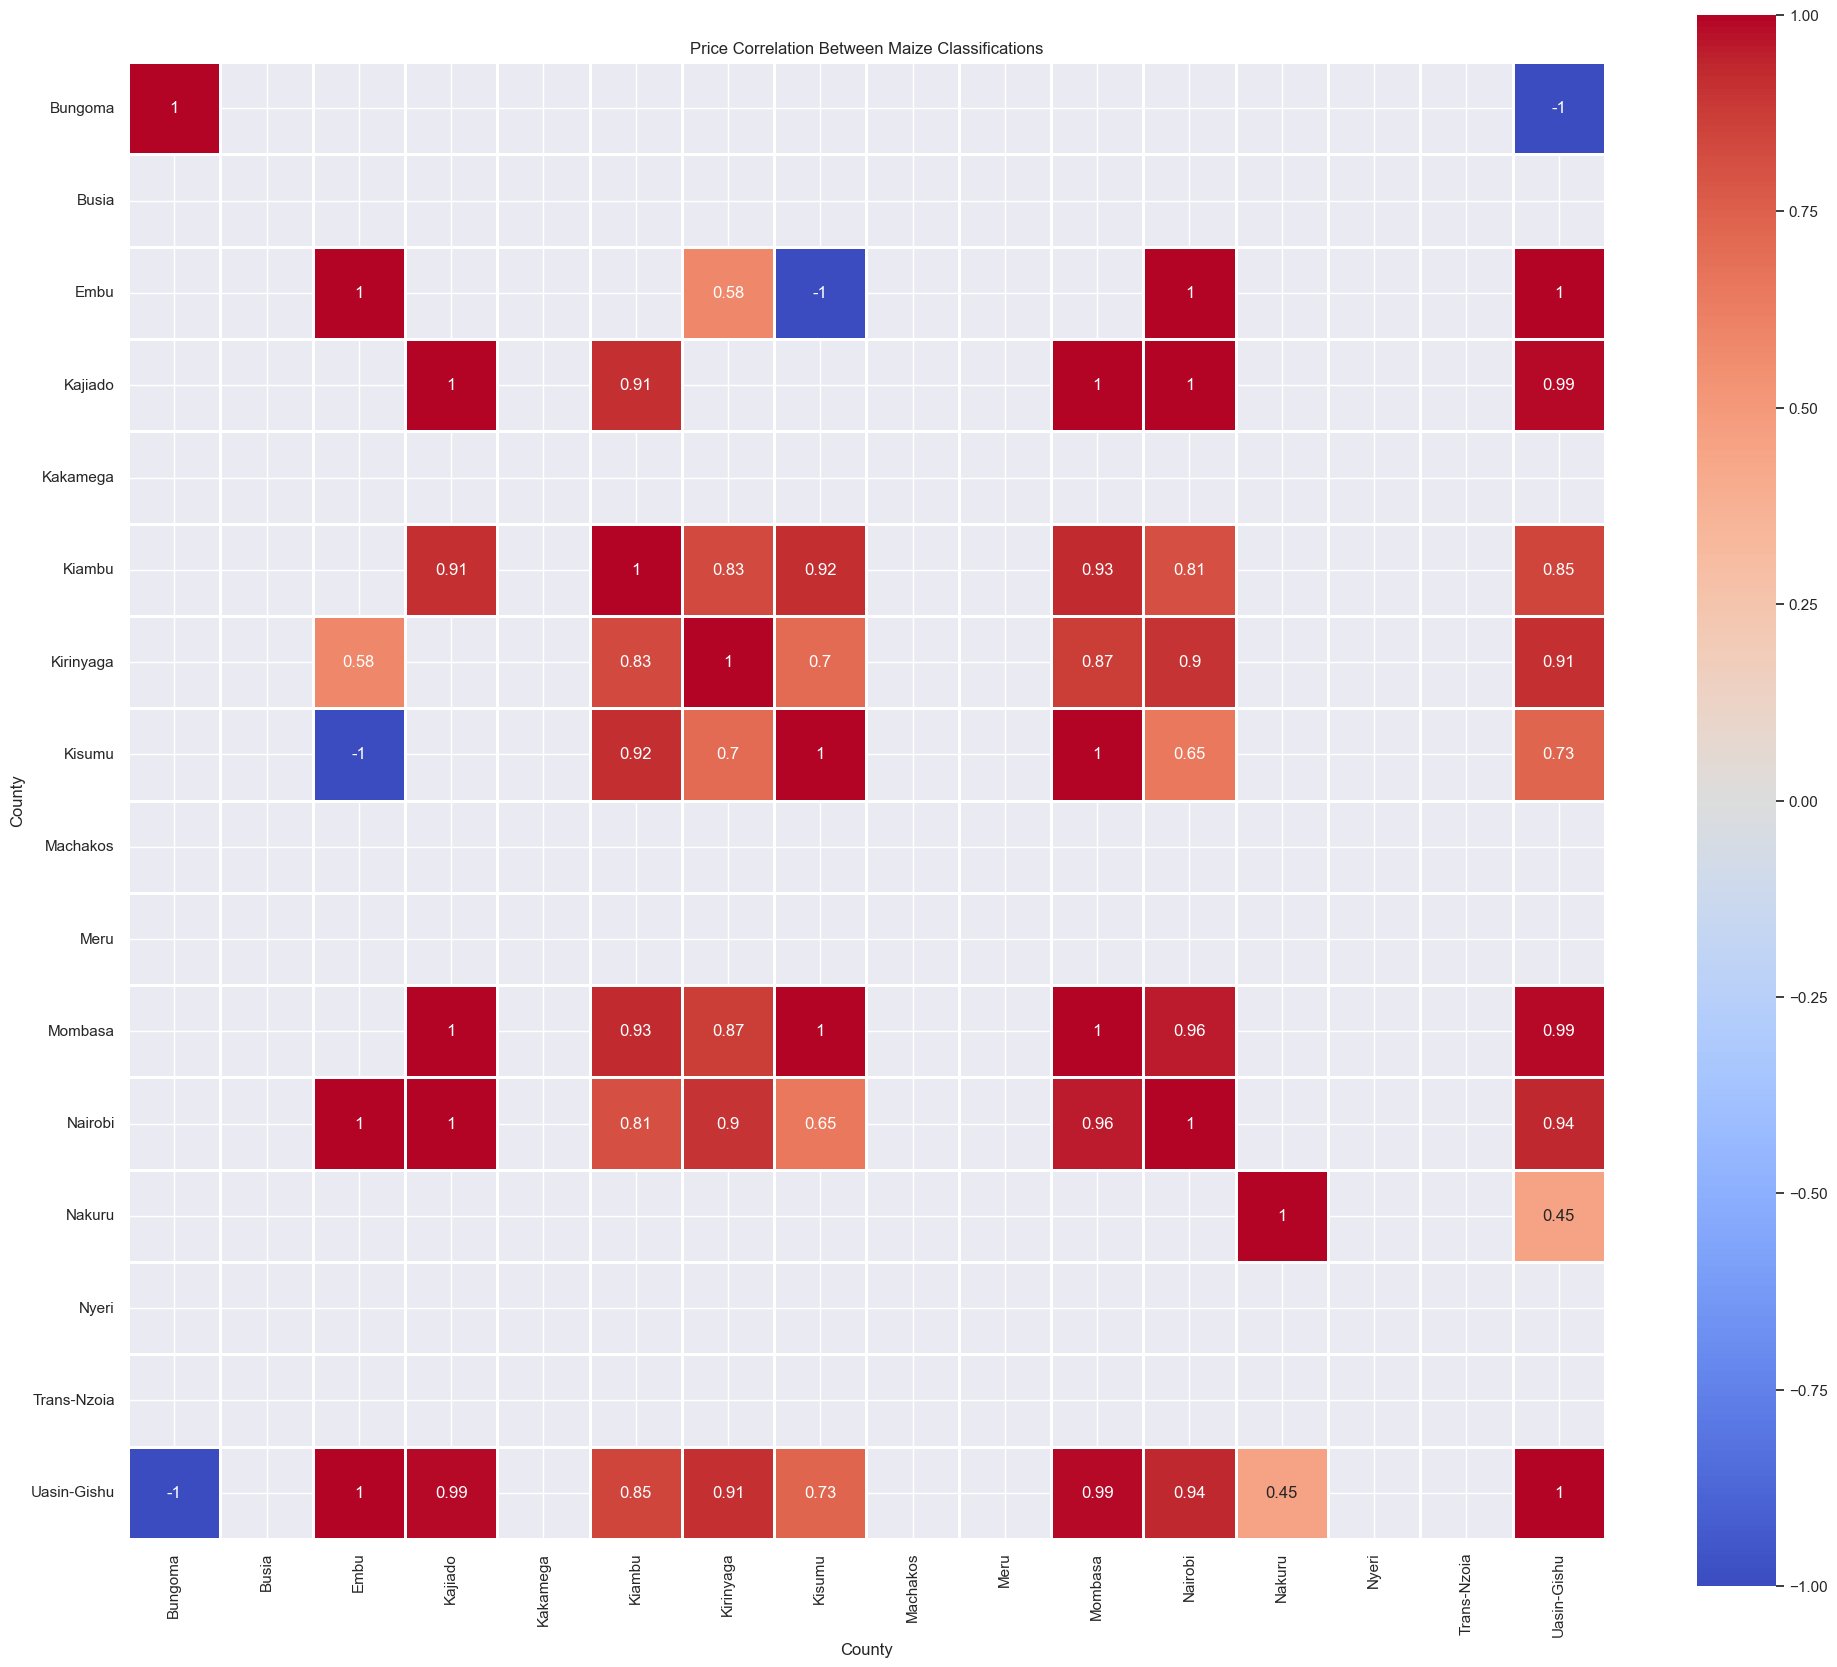

In [1193]:

pivot_data = df_agri.pivot_table(values='WholeSale', index='Year_Week', columns='County', aggfunc='mean')
# Calculate correlation
correlation = pivot_data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Price Correlation Between Maize Classifications')
plt.tight_layout()
plt.show()

In [1194]:
missing_pct = pivot_data.isna().mean().sort_values(ascending=False)
missing_pct.head(15)

County
Busia          0.989011
Kakamega       0.989011
Machakos       0.989011
Meru           0.989011
Nyeri          0.978022
Trans-Nzoia    0.978022
Embu           0.967033
Kajiado        0.967033
Nakuru         0.967033
Bungoma        0.945055
Kisumu         0.835165
Mombasa        0.813187
Kirinyaga      0.725275
Kiambu         0.670330
Nairobi        0.384615
dtype: float64

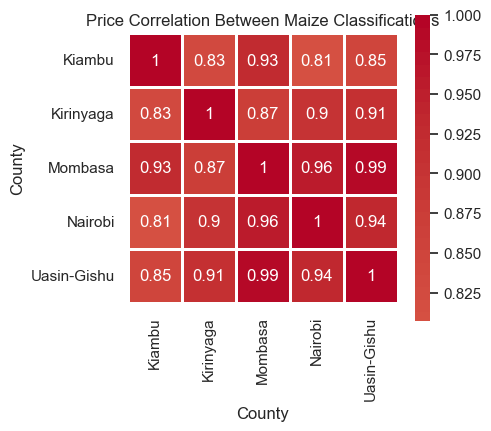

In [1195]:
target_counties = {"Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"}
filtered_data = df_agri[df_agri['County'].isin(target_counties)]

pivot_data = filtered_data.pivot_table(values='WholeSale', index='Year_Week', columns='County', aggfunc='mean')
# Calculate correlation
correlation = pivot_data.corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Price Correlation Between Maize Classifications')
plt.tight_layout()
plt.show()

In [1196]:
df_full.grain.unique()

array(['Beans (Yellow-Green)__-', 'Dry Maize__Mixed-Traditional',
       'Dry Maize__White Maize', 'Dry Maize__Yellow Maize',
       'Green Grams__Local-Special', 'Ground Nuts__Large Brown',
       'Rice__Irr', 'Wheat__-'], dtype=object)

In [1197]:
df_full

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,SV_mean,SV_median,SV_std
0,Beans (Yellow-Green)__-,Bomet,2023-04-03,116.670000,116.670000,11.006255,100.000000,100.000000,9.856054,180.000000,180.000000,1195.783160
1,Beans (Yellow-Green)__-,Bomet,2023-04-10,205.000000,205.000000,0.000000,200.000000,200.000000,0.000000,9000.000000,9000.000000,0.000000
2,Beans (Yellow-Green)__-,Bomet,2023-04-17,106.670000,106.670000,0.000000,100.000000,100.000000,0.000000,9000.000000,9000.000000,0.000000
3,Beans (Yellow-Green)__-,Bomet,2023-04-24,275.000000,275.000000,0.000000,240.000000,240.000000,0.000000,12000.000000,12000.000000,0.000000
4,Beans (Yellow-Green)__-,Bomet,2023-05-01,116.670000,116.670000,0.000000,100.000000,100.000000,0.000000,13500.000000,13500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
32179,Wheat__-,Uasin-Gishu,2025-01-13,97.711257,97.303359,9.864383,84.088224,83.733116,6.943689,1881.395936,2030.600335,836.288774
32180,Wheat__-,Uasin-Gishu,2025-01-27,97.711257,97.303359,9.864383,84.088224,83.733116,6.943689,1881.395936,2030.600335,836.288774
32181,Wheat__-,Uasin-Gishu,2025-02-03,97.711257,97.303359,9.864383,84.088224,83.733116,6.943689,1881.395936,2030.600335,836.288774
32182,Wheat__-,Uasin-Gishu,2025-03-03,97.711257,97.303359,9.864383,84.088224,83.733116,6.943689,1881.395936,2030.600335,836.288774


In [1198]:
df_agri['Date'] = pd.to_datetime(df_agri['Date'])
df_agri['WeekofYear'] = df_agri['Date'].dt.isocalendar().week.astype(int)
df_agri['grain'] = 'Dry Maize__White Maize'

In [1199]:
df_agri

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,grain
0,Nairobi,2023-10-03,50.00,Dry_White_Maize,2023-40,40,Dry Maize__White Maize
1,Kirinyaga,2023-10-03,48.89,Dry_White_Maize,2023-40,40,Dry Maize__White Maize
2,Kisumu,2023-10-03,44.44,Dry_White_Maize,2023-40,40,Dry Maize__White Maize
3,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40,Dry Maize__White Maize
4,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40,Dry Maize__White Maize
...,...,...,...,...,...,...,...
803,Uasin-Gishu,2025-10-06,36.67,Dry_White_Maize,2025-40,41,Dry Maize__White Maize
804,Uasin-Gishu,2025-10-06,38.89,Dry_White_Maize,2025-40,41,Dry Maize__White Maize
805,Uasin-Gishu,2025-10-06,38.89,Dry_White_Maize,2025-40,41,Dry Maize__White Maize
806,Uasin-Gishu,2025-09-24,NaN,Dry_White_Maize,2025-38,39,Dry Maize__White Maize


In [1200]:
df_scraped = df_full.copy()
df_scraped = df_scraped.sort_values('year_week')

# Scraped
df_scraped['Date'] = pd.to_datetime(df_scraped['year_week'])
df_scraped['Year'] = df_scraped['Date'].dt.year
df_scraped['WeekofYear'] = df_scraped['Date'].dt.isocalendar().week.astype(int)

In [1201]:
df_scraped.shape

(32184, 15)

In [1179]:
df_merged = df_scraped.merge(
    df_agri,
    how='inner',
    on=['grain', 'County', 'Date']
).sort_index()


In [1180]:
df_merged.shape

(186, 19)

In [1181]:
df_merged.head()

,grain,County,year_week,retail_mean,retail_median,retail_std,price_mean,price_median,price_std,SV_mean,SV_median,SV_std,Date,Year,WeekofYear_x,WholeSale,Commodity_Classification,Year_Week,WeekofYear_y
0,Dry Maize__White Maize,Kajiado,2025-08-04,67.961052,67.358188,7.723684,56.558334,56.067973,6.992896,5632.127242,5669.687232,1906.50215,2025-08-04,2025,32,42.22,Dry_White_Maize,2025-31,32
1,Dry Maize__White Maize,Kajiado,2025-08-11,67.961052,67.358188,7.723684,56.558334,56.067973,6.992896,5632.127242,5669.687232,1906.50215,2025-08-11,2025,33,38.89,Dry_White_Maize,2025-32,33
2,Dry Maize__White Maize,Kajiado,2025-08-18,67.961052,67.358188,7.723684,56.558334,56.067973,6.992896,5632.127242,5669.687232,1906.50215,2025-08-18,2025,34,38.89,Dry_White_Maize,2025-33,34
3,Dry Maize__White Maize,Kiambu,2025-08-04,67.961052,67.358188,7.723684,56.558334,56.067973,6.992896,5632.127242,5669.687232,1906.50215,2025-08-04,2025,32,44.22,Dry_White_Maize,2025-31,32
4,Dry Maize__White Maize,Kiambu,2025-09-29,67.961052,67.358188,7.723684,56.558334,56.067973,6.992896,5632.127242,5669.687232,1906.50215,2025-09-29,2025,40,41.11,Dry_White_Maize,2025-39,40


In [1182]:
df_merged.County.unique()

array(['Kajiado', 'Kiambu', 'Kirinyaga', 'Kisumu', 'Mombasa', 'Nairobi',
       'Uasin-Gishu'], dtype=object)

In [1183]:
df_merged.WeekofYear_x.nunique()

34

In [1184]:
plot_df = df_merged.melt(
    id_vars=['Year_Week'],
    value_vars=['price_mean', 'WholeSale', 'retail_mean'],
    var_name='Source',
    value_name='Price'
)

In [1688]:
agribora = pd.read_csv('agriBORA_maize_prices_weeks_46_to_51.csv')
agribora['ID'] = agribora['County'] +'_Week_' + agribora['Year_Week'].str.split('-').str[1]
sub0 = agribora[agribora['WeekofYear'] > 47]

In [1689]:
agribora

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,ID
0,Kiambu,2025-11-10,38.333333,Dry_White_Maize,2025-46,46,Kiambu_Week_46
1,Kirinyaga,2025-11-10,38.888889,Dry_White_Maize,2025-46,46,Kirinyaga_Week_46
2,Mombasa,2025-11-10,36.111111,Dry_White_Maize,2025-46,46,Mombasa_Week_46
3,Nairobi,2025-11-10,36.800000,Dry_White_Maize,2025-46,46,Nairobi_Week_46
4,Uasin-Gishu,2025-11-10,33.222222,Dry_White_Maize,2025-46,46,Uasin-Gishu_Week_46
5,Kiambu,2025-11-17,38.330000,Dry_White_Maize,2025-47,47,Kiambu_Week_47
6,Kirinyaga,2025-11-17,38.890000,Dry_White_Maize,2025-47,47,Kirinyaga_Week_47
7,Mombasa,2025-11-17,36.110000,Dry_White_Maize,2025-47,47,Mombasa_Week_47
8,Nairobi,2025-11-17,36.748571,Dry_White_Maize,2025-47,47,Nairobi_Week_47
9,Uasin-Gishu,2025-11-17,32.777143,Dry_White_Maize,2025-47,47,Uasin-Gishu_Week_47


In [1373]:
sub = agribora.groupby(['County'])['WholeSale'].mean().reset_index()

In [1374]:
sub['ID'] = sub['County'] + '_Week_50'

In [1375]:
sub1 = sub.copy()
sub1['WholeSale'] += -1
sub1['ID'] = sub2['ID'].apply(lambda x:x[:-1] + '1')
sub2 = sub.copy()
sub2['WholeSale'] += 0
sub2['ID'] = sub2['ID'].apply(lambda x:x[:-1] + '2')

In [1376]:
sub3 = sub.copy()
sub3['WholeSale'] = 0.0
sub3['ID'] = sub2['ID'].apply(lambda x:x[:-2] + '1')
sub4 = sub.copy()
sub4['WholeSale'] = 0.0
sub4['ID'] = sub2['ID'].apply(lambda x:x[:-2] + '2')

In [1377]:
final = pd.concat([sub0, sub, sub1, sub2, sub3, sub4])

In [1378]:
final['Target_RMSE'] = final['WholeSale']
final['Target_MAE'] = final['WholeSale']

In [1379]:
final[['ID', 'Target_RMSE', 'Target_MAE']].to_csv('baseline.csv', index = False)

In [1380]:
final

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,ID,Target_RMSE,Target_MAE
10,Kiambu,2025-11-24,37.780000,Dry_White_Maize,2025-48,48.0,Kiambu_Week_48,37.780000,37.780000
11,Kirinyaga,2025-11-24,38.330000,Dry_White_Maize,2025-48,48.0,Kirinyaga_Week_48,38.330000,38.330000
12,Mombasa,2025-11-24,36.110000,Dry_White_Maize,2025-48,48.0,Mombasa_Week_48,36.110000,36.110000
13,Nairobi,2025-11-24,36.807500,Dry_White_Maize,2025-48,48.0,Nairobi_Week_48,36.807500,36.807500
14,Uasin-Gishu,2025-11-24,32.554000,Dry_White_Maize,2025-48,48.0,Uasin-Gishu_Week_48,32.554000,32.554000
15,Kiambu,2025-12-01,39.445000,Dry_White_Maize,2025-49,49.0,Kiambu_Week_49,39.445000,39.445000
16,Kirinyaga,2025-12-01,40.000000,Dry_White_Maize,2025-49,49.0,Kirinyaga_Week_49,40.000000,40.000000
17,Mombasa,2025-12-01,36.110000,Dry_White_Maize,2025-49,49.0,Mombasa_Week_49,36.110000,36.110000
18,Nairobi,2025-12-01,37.848750,Dry_White_Maize,2025-49,49.0,Nairobi_Week_49,37.848750,37.848750
19,Uasin-Gishu,2025-12-01,33.334000,Dry_White_Maize,2025-49,49.0,Uasin-Gishu_Week_49,33.334000,33.334000
